# CMPE 256 - Research Paper Citation Recommender

**Team:** The ArXivists

| Name | SJSU ID |
|---|---|
| Sheetal Sattiraju | 014178047 |
| Talina Shrotriya | 018260437 |
| Manjula Ganesh | 018227469 |

---

**Goal:** Given a research paper, recommend the papers most likely to be cited alongside it.

**Approach:** Citation links encode semantic similarity that plain-text search misses. Two papers on
the same topic may share no vocabulary yet appear together in thousands of reference lists.
This notebook exploits that co-citation signal with collaborative filtering and compares it against
a TF-IDF baseline to measure the gain from structural information.

**Dataset scope:** up to 100,000 papers per OAI set from arXiv, covering cs, math, physics, stat, eess,
q-bio (quantitative biology), q-fin (finance), and econ (economics), years 2015-2025 (~800k papers total).

---

| Section | Description |
|---|---|
| **0 - Setup** | Install dependencies, imports, Google Drive, configuration |
| **1 - Data Gathering** | Fetch ~800k paper metadata records from arXiv OAI-PMH across 8 domains |
| **2 - Citation Links** | Fetch citation edges for each paper from Semantic Scholar |
| **3 - Data Merging** | Join sources, build integer index (cold-start filter applied per model) |
| **4 - EDA** | Understand paper distribution, citation graph structure, and coverage |
| **5 - Evaluation Framework** | Shared train/test split and reusable evaluate_model / compare_models |
| **6 - TF-IDF Baseline** | Content-similarity baseline; evaluate Precision / Recall / NDCG@K |
| **7 - Advanced Models** | SVD, PageRank, PPR-MC, TF-IDF+PPR-MC, GMF, Epsilon-Greedy, NeuMF, Hybrid TF-IDF+SVD |
| **8 - Export** | Download output files from Google Drive |

**Output files (Drive folder: cmpe_256_project_files):**

| File | Contents |
|---|---|
| `papers.csv` | paper_idx, arxiv_id, title, abstract, categories, year, s2_fields, cite_pop |
| `citations.csv` | source_idx, target_idx (integer indices, in-sample only) |
| `tfidf_vectorizer.pkl` | Fitted TF-IDF vectorizer |
| `tfidf_matrix.npz` | Pre-built TF-IDF sparse matrix |
| `paper_embeddings.npy` | 128-dim citation-graph SVD embeddings |
| `pagerank_vector.npy` | Global PageRank scores per paper |
| `hybrid_embeddings.npy` | 128-dim text-SVD embeddings (Hybrid TF-IDF+SVD) |
| `gmf_model.pt` | GMF model weights |
| `neumf_model.pt` | NeuMF model weights |


---
## Section 0 - Setup

**Goals:**
- Install required packages
- Import all libraries used across the notebook
- Mount Google Drive as the persistent output directory
- Define global configuration parameters

**Validation:** Confirm imports succeed and the output directory is accessible.

In [1]:
!pip install -q sickle tqdm implicit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 89.8 MB/s eta 0:00:00


In [2]:
import json
import re
import time
import pickle
import threading
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from xml.etree.ElementTree import fromstring as _xml_parse

import requests

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import networkx as nx
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.model_selection import train_test_split
from sickle import Sickle as _Sickle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from IPython.display import Markdown, display


In [3]:
# Validate that critical imports resolved.
_required = ["np", "pd", "nx", "torch", "TfidfVectorizer", "TruncatedSVD", "requests"]
for _name in _required:
    assert _name in dir() or _name in globals(), f"Missing import: {_name}"
print("Imports OK")

Imports OK


In [4]:
from google.colab import drive
drive.mount("/content/drive")

OUTPUT_DIR = Path("/content/drive/MyDrive/cmpe_256_project_files")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [9]:
assert OUTPUT_DIR.exists(), f"OUTPUT_DIR not found: {OUTPUT_DIR}"
print(f"Output directory: {OUTPUT_DIR}")

Output directory: /content/drive/MyDrive/cmpe_256_project_files


In [10]:
# ---- arXiv domain coverage ----
# Target the top-level OAI-PMH sets; one set = one arXiv subject area.
# Each set is fetched independently so quota control is per-domain.
OAI_SETS: list[str] = ["cs", "math", "physics", "stat", "eess", "q-bio", "q-fin", "econ"]

# Filter: keep a paper only if at least one of its categories starts with one
# of these prefixes (matches cs.LG, math.ST, physics.comp-ph, etc.)
TARGET_PREFIXES: set[str] = {"cs", "math", "physics", "stat", "eess", "q-bio", "q-fin", "econ"}

# Backward-compat alias used by the evaluation validation cell
TARGET_CATS = TARGET_PREFIXES

# Target this many papers per OAI set; the fetch stops early once reached.
PAPERS_PER_SET: int = 100_000

# Global ceiling (safety cap - 8 sets x 500k = 4M nominal)
MAX_PAPERS: int = 3_000_000

# ---- year range ----
MIN_YEAR: int = 2015
MAX_YEAR: int = 2025

# ---- cold-start threshold ----
MIN_DEGREE: int = 2

# ---- Semantic Scholar API ----
# Rate limits by tier:
#   no key / free key (Tier 1) : 1 req/s  - use S2_WORKERS=1
#   Tier 2 (request at s2.org) : 10 req/s - set S2_RPS=9.0, S2_WORKERS=5
try:
    from google.colab import userdata as _ud
    S2_API_KEY: str = _ud.get("SEMANTIC_API_KEY") or ""
except Exception:
    S2_API_KEY: str = ""

S2_ENDPOINT: str   = "https://api.semanticscholar.org/graph/v1/paper/batch"
S2_FIELDS: str     = "references.externalIds,fieldsOfStudy"
S2_BATCH_SIZE: int = 500
S2_RPS: float      = 9.0
S2_WORKERS: int    = 5
S2_CKPT_EVERY: int = 100

# ---- arXiv OAI-PMH ----
OAI_ENDPOINT: str = "http://export.arxiv.org/oai2"

# (set x year) tasks run concurrently; reduce to 10-12 if arXiv returns 503s
OAI_WORKERS: int = min(len(OAI_SETS) * (MAX_YEAR - MIN_YEAR + 1), 40)


# Per-set ETA hint for tqdm during the OAI-PMH fetch.
# Set to PAPERS_PER_SET for all domains since we are targeting 100k each.
_SET_TOTAL_EST: dict[str, int] = {
    "cs":      100_000,
    "math":    100_000,
    "physics": 100_000,
    "stat":    100_000,
    "eess":    100_000,
    "q-bio":   100_000,
    "q-fin":   100_000,
    "econ":    100_000,
}

# True upper bound of what arXiv OAI-PMH actually has per domain (all years combined).
# Used ONLY by the cache-check threshold so small domains (econ, q-fin, q-bio) can
# pass the check after a full fetch even though they never reach PAPERS_PER_SET.
_DOMAIN_MAX_REALISTIC: dict[str, int] = {
    "cs":      700_000,
    "math":    450_000,
    "physics": 550_000,
    "stat":     95_000,
    "eess":     75_000,
    "q-bio":    35_000,
    "q-fin":    14_000,
    "econ":      9_000,
}

# ---- reproducibility ----
import numpy as np
np.random.seed(256)

# Guard: do not override OUTPUT_DIR set by the Drive-mount cell above.
if "OUTPUT_DIR" not in vars():
    from pathlib import Path
    OUTPUT_DIR = Path(".")

print("config loaded")
print(f"  OAI sets     : {OAI_SETS}")
print(f"  papers/set   : {PAPERS_PER_SET:,}")
print(f"  year range   : {MIN_YEAR}-{MAX_YEAR}")
print(f"  S2 API key   : {'set' if S2_API_KEY else 'not set (public rate limit)'}")
print(f"  output dir   : {OUTPUT_DIR}")


config loaded
  OAI sets     : ['cs', 'math', 'physics', 'stat', 'eess', 'q-bio', 'q-fin', 'econ']
  papers/set   : 100,000
  year range   : 2015-2025
  S2 API key   : set
  output dir   : /content/drive/MyDrive/cmpe_256_project_files


In [11]:
def _check_cached_dataset():
    """
    Load cached CSVs and verify every target category has papers and citations.

    Returns (df_papers, df_cits, ok, issues).
    ok=True means the cache is complete and the pipeline can be skipped.
    ok=False means one or more categories are missing or under-populated;
    the caller should re-run the full pipeline rather than use partial data.
    """
    _papers_path = OUTPUT_DIR / "papers.csv"
    _cits_path   = OUTPUT_DIR / "citations.csv"

    if not _papers_path.exists() or not _cits_path.exists():
        return None, None, False, ["papers.csv or citations.csv not found"]

    df_p = pd.read_csv(_papers_path, dtype={"arxiv_id": str})
    df_c = pd.read_csv(_cits_path)

    issues = []

    # Minimum acceptable papers per category.
    # Cap at half the realistic domain maximum so small domains (econ, q-fin, q-bio)
    # can pass the check after fetching everything available, even if well below
    # PAPERS_PER_SET. Large domains still require at least PAPERS_PER_SET // 2.
    def _min_for(prefix):
        realistic_half = _DOMAIN_MAX_REALISTIC.get(prefix, PAPERS_PER_SET) // 2
        return min(PAPERS_PER_SET // 2, realistic_half)

    def _primary_prefix(cats_str):
        """Return the domain prefix of the first matching category."""
        for cat in str(cats_str).split():
            prefix = cat.split(".")[0] if "." in cat else cat
            if prefix in TARGET_PREFIXES:
                return prefix
        return None

    df_p["_prefix"] = df_p["categories"].apply(_primary_prefix)

    # Papers that appear as a citation source (have at least one outgoing edge)
    papers_with_outgoing = set(df_c["source_idx"].unique())

    for prefix in sorted(TARGET_PREFIXES):
        sub = df_p[df_p["_prefix"] == prefix]
        n_papers = len(sub)
        n_citing  = sub["paper_idx"].isin(papers_with_outgoing).sum()

        _threshold = _min_for(prefix)
        if n_papers < _threshold:
            issues.append(
                f"  {prefix:<10}: {n_papers:>6,} papers "
                f"(minimum {_threshold:,}) -- too few, will re-fetch"
            )
        elif n_citing == 0:
            issues.append(
                f"  {prefix:<10}: {n_papers:>6,} papers "
                f"but 0 with outgoing citations -- S2 fetch incomplete"
            )
        else:
            print(
                f"  {prefix:<10}: {n_papers:>6,} papers, "
                f"{n_citing:>6,} with citations  OK"
            )

    df_p = df_p.drop(columns=["_prefix"])
    return df_p, df_c, len(issues) == 0, issues


print("Checking cached dataset coverage ...")
df_papers_f, df_cit_f, _cache_ok, _cache_issues = _check_cached_dataset()

if _cache_ok:
    s2_fields_map: dict = {}
    SKIP_PIPELINE = True
    print(f"\nCache is complete - pipeline will be skipped.")
    print(f"  papers.csv   : {len(df_papers_f):,} rows")
    print(f"  citations.csv: {len(df_cit_f):,} rows")
else:
    SKIP_PIPELINE = False
    if _cache_issues == ["papers.csv or citations.csv not found"]:
        print("  No cached files found.")
    else:
        print("\nCache is incomplete - pipeline will run:")
        for issue in _cache_issues:
            print(issue)
    print("\nRunning full pipeline.")

Checking cached dataset coverage ...
  cs        : 156,833 papers, 59,416 with citations  OK
  econ      :  9,688 papers,  2,584 with citations  OK
  eess      : 55,113 papers, 22,636 with citations  OK
  math      : 96,100 papers, 27,063 with citations  OK
  physics   : 93,559 papers, 23,404 with citations  OK
  q-bio     : 23,762 papers,  5,636 with citations  OK
  q-fin     :  9,293 papers,  3,030 with citations  OK

Cache is incomplete - pipeline will run:
  stat      : 42,568 papers (minimum 47,500) -- too few, will re-fetch

Running full pipeline.


In [12]:
print(f"SKIP_PIPELINE = {SKIP_PIPELINE}")
if SKIP_PIPELINE:
    assert df_papers_f is not None and not df_papers_f.empty
    assert df_cit_f    is not None and not df_cit_f.empty
    print(f"Ready: {len(df_papers_f):,} papers, {len(df_cit_f):,} citation edges")

SKIP_PIPELINE = False


In [13]:
SKIP_PIPELINE = True

---
## Section 1 - Data Gathering: arXiv Paper Metadata

**Goals:**
- Harvest paper metadata (title, abstract, categories, submission date) from arXiv via OAI-PMH
- Cover all 8 target domains: cs, math, physics, stat, eess, q-bio, q-fin, econ
- Collect at least 10,000 papers per OAI set

**What the cells do:**
1. Define `extract_year` and `clean_text` helpers
2. Define `_parse_record` to parse a single OAI-PMH XML record, filtering by TARGET_PREFIXES
3. Define `_fetch_year` to fetch one (set, year) shard with per-task checkpointing
4. Define `load_oai_arxiv` to run all shards concurrently, enforcing PAPERS_PER_SET
5. Execute the fetch and run a sanity check on the resulting DataFrame

**Criteria:**
- All 8 TARGET_PREFIXES are represented in the fetched categories
- Years are within [MIN_YEAR, MAX_YEAR]
- No null arxiv_id values
- At least PAPERS_PER_SET papers per set (or all available if fewer exist)

In [14]:
def extract_year(arxiv_id: str, fallback_date: str = "") -> int | None:
    """
    Get the submission year from an arXiv ID.

    relied on the YYMM prefix in new-format IDs (post-2007) because it always
    reflects the v1 submission date. fallen back to the update_date string only
    for old-style IDs that predate this format.
    """
    match = re.match(r"^(\d{2})\d{2}\.\d+", arxiv_id)
    if match:
        yy = int(match.group(1))
        return 2000 + yy if yy < 90 else 1900 + yy
    if len(fallback_date) >= 4:
        try:
            return int(fallback_date[:4])
        except ValueError:
            pass
    return None


def clean_text(text: str | None) -> str:
    """Collapse whitespace and strip leading/trailing spaces."""
    if not text:
        return ""
    return re.sub(r"\s+", " ", text).strip()

In [15]:
from sickle import Sickle as _Sickle
from xml.etree.ElementTree import fromstring as _xml_parse

_ARXIV_NS_DBG = "http://arxiv.org/OAI/arXiv/"
_sickle = _Sickle(OAI_ENDPOINT)
_records = _sickle.ListRecords(
    metadataPrefix="arXiv",
    set="cs",
    **{"from": "2023-01-01", "until": "2023-01-03"},
)

# Fetch 3 records to confirm the arXiv prefix returns clean category codes
for _i, _rec in enumerate(_records):
    print(f"--- record {_i} ---")
    print(f"header.identifier : {_rec.header.identifier}")
    _root = _xml_parse(_rec.raw)
    _el = _root.find(f".//{{{_ARXIV_NS_DBG}}}arXiv")
    if _el is not None:
        print(f"categories        : {_el.findtext(f'{{{_ARXIV_NS_DBG}}}categories')}")
        print(f"title             : {(_el.findtext(f'{{{_ARXIV_NS_DBG}}}title') or '')[:80]}")
    print()
    if _i >= 2:
        break

--- record 0 ---
header.identifier : oai:arXiv.org:1711.06529
categories        : math.NA cond-mat.mtrl-sci
title             : Variational projector augmented-wave method: theoretical analysis and preliminar

--- record 1 ---
header.identifier : oai:arXiv.org:1712.04685
categories        : math.NA cond-mat.mtrl-sci
title             : Projector augmented-wave method: an analysis in a one-dimensional setting

--- record 2 ---
header.identifier : oai:arXiv.org:1810.01329
categories        : math.NA cond-mat.mtrl-sci
title             : Discretization error cancellation in the plane-wave approximation of periodic Ha



In [16]:
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from xml.etree.ElementTree import fromstring as _xml_parse
from tqdm import tqdm

# arXiv OAI-PMH namespace for the arXiv metadata prefix
_ARXIV_NS = "http://arxiv.org/OAI/arXiv/"

# _SET_TOTAL_EST is defined in the config cell and used here for tqdm ETA.


def _parse_record(record) -> dict | None:
    """
    Extract one paper's fields from a sickle arXiv-prefix OAI-PMH record.

    Uses metadataPrefix="arXiv" because oai_dc puts human-readable strings in
    dc:subject (e.g. "Computer Science - Machine Learning") that do not match
    arXiv category codes. The arXiv prefix has a dedicated <categories> element
    with space-separated codes like "cs.LG stat.ML", enabling exact prefix matching.

    Returns None if the record did not match TARGET_PREFIXES or the year range.
    """
    try:
        oai_id = record.header.identifier
        arxiv_id = re.sub(r"v\d+$", "", oai_id.split("oai:arXiv.org:")[-1]).strip()
        if not arxiv_id:
            return None

        year = extract_year(arxiv_id)
        if year is None or not (MIN_YEAR <= year <= MAX_YEAR):
            return None

        root = _xml_parse(record.raw)
        arxiv_el = root.find(f".//{{{_ARXIV_NS}}}arXiv")
        if arxiv_el is None:
            return None

        cats_str = (arxiv_el.findtext(f"{{{_ARXIV_NS}}}categories") or "").strip()
        cats = cats_str.split()

        # Keep the paper if any category starts with one of the target prefixes.
        # This matches cs.LG, math.ST, q-bio.QM, etc. without maintaining a
        # full list of every arXiv subcategory.
        def _prefix(cat):
            return cat.split(".")[0] if "." in cat else cat

        if not any(_prefix(c) in TARGET_PREFIXES for c in cats):
            return None

        title    = clean_text(arxiv_el.findtext(f"{{{_ARXIV_NS}}}title") or "")
        abstract = clean_text(arxiv_el.findtext(f"{{{_ARXIV_NS}}}abstract") or "")

        authors_list = []
        for author_el in arxiv_el.findall(
            f"{{{_ARXIV_NS}}}authors/{{{_ARXIV_NS}}}author"
        ):
            keyname   = author_el.findtext(f"{{{_ARXIV_NS}}}keyname") or ""
            forenames = author_el.findtext(f"{{{_ARXIV_NS}}}forenames") or ""
            if keyname:
                authors_list.append(f"{forenames} {keyname}".strip())

        return {
            "arxiv_id":   arxiv_id,
            "title":      title,
            "abstract":   abstract,
            "categories": " ".join(cats),
            "authors":    "; ".join(authors_list),
            "year":       year,
        }
    except Exception:
        return None


def _fetch_year(
    oai_set: str,
    year: int,
    papers_per_set: int = PAPERS_PER_SET,
) -> tuple[str, int, list[dict]]:
    """
    Fetch matching papers from one OAI-PMH set for a single calendar year.

    Resume / top-up logic:
    - If a checkpoint exists AND it already meets the per-year quota, return it
      immediately (no network call).
    - If a checkpoint exists but is under-quota AND the stream was not previously
      exhausted, re-fetch from scratch; existing IDs are deduped so only new
      records are appended.
    - A zero-byte sentinel file (_ckpt_oai_{set}_{year}.exhausted) marks streams
      where OAI-PMH returned every available record before reaching the quota.
      Those shards are never re-fetched even if they are under-quota.

    Checkpoint writes use .tmp -> rename to prevent partial files on crash.
    Returns (oai_set, year, rows) so the caller can log per-task completions.
    """
    ckpt_path      = OUTPUT_DIR / f"_ckpt_oai_{oai_set}_{year}.csv"
    exhaust_marker = OUTPUT_DIR / f"_ckpt_oai_{oai_set}_{year}.exhausted"

    n_years       = MAX_YEAR - MIN_YEAR + 1
    per_year_quota = papers_per_set // n_years

    # Load any existing rows from a prior run.
    rows: list[dict] = []
    seen_ids: set[str] = set()
    if ckpt_path.exists():
        rows = pd.read_csv(ckpt_path, dtype=str).to_dict("records")
        seen_ids = {r["arxiv_id"] for r in rows}

    # Skip if already at quota, or if the stream is known to be exhausted.
    if len(rows) >= per_year_quota or exhaust_marker.exists():
        status = "exhausted" if exhaust_marker.exists() else "full"
        tqdm.write(
            f"  [{oai_set}/{year}] checkpoint: {len(rows):,} papers ({status}, skipping fetch)"
        )
        return oai_set, year, rows

    # Need more records (either no checkpoint yet, or a partial one).
    if rows:
        tqdm.write(
            f"  [{oai_set}/{year}] topping up: {len(rows):,}/{per_year_quota:,} cached, fetching more..."
        )

    from sickle import Sickle

    sickle = Sickle(OAI_ENDPOINT, max_retries=3, retry_status_codes=[503, 429])
    est = _SET_TOTAL_EST.get(oai_set, 50_000) // n_years
    exhausted = False

    try:
        records = sickle.ListRecords(
            metadataPrefix="arXiv",
            set=oai_set,
            **{"from": f"{year}-01-01", "until": f"{year}-12-31"},
        )
        with tqdm(
            records,
            desc=f"  {oai_set}/{year}",
            total=est,
            leave=False,
            unit=" rec",
            dynamic_ncols=True,
        ) as pbar:
            for record in pbar:
                row = _parse_record(record)
                if row and row["arxiv_id"] not in seen_ids:
                    rows.append(row)
                    seen_ids.add(row["arxiv_id"])
                pbar.set_postfix(kept=f"{len(rows):,}")
                if len(rows) >= per_year_quota:
                    break
            else:
                # for-loop completed without break: stream fully consumed.
                exhausted = True

    except Exception as exc:
        tqdm.write(f"  [{oai_set}/{year}] stopped: {type(exc).__name__}: {exc}")

    finally:
        # Save whatever was collected, even on KeyboardInterrupt (stop button).
        # except Exception does not catch KeyboardInterrupt, so without finally
        # a mid-fetch stop would discard all progress for this shard.
        if rows:
            tmp = ckpt_path.with_suffix(".tmp")
            pd.DataFrame(rows).to_csv(tmp, index=False)
            tmp.rename(ckpt_path)

        if exhausted:
            exhaust_marker.touch()
            tqdm.write(
                f"  [{oai_set}/{year}] stream exhausted: {len(rows):,} total (no more records available)"
            )
        else:
            tqdm.write(f"  [{oai_set}/{year}] done: {len(rows):,} matched -> saved to {ckpt_path.name}")

    return oai_set, year, rows


def load_oai_arxiv(
    min_year: int = MIN_YEAR,
    max_year: int = MAX_YEAR,
    max_papers: int | None = MAX_PAPERS,
    papers_per_set: int = PAPERS_PER_SET,
    oai_sets: list[str] | None = None,
    workers: int = OAI_WORKERS,
) -> pd.DataFrame:
    """
    Fetch arXiv paper metadata from OAI-PMH with concurrent per-(set, year) streams.

    Work is split into one task per (set x year) pair. Tasks with existing checkpoint
    files in OUTPUT_DIR are loaded instantly and skipped, so a resumed run only
    fetches whatever was not yet completed.

    Args:
        min_year: Earliest submission year to include (inclusive).
        max_year: Latest submission year to include (inclusive).
        max_papers: Global cap on total unique papers. None = no cap.
        papers_per_set: Target papers per OAI set (enforced per-year slice).
        oai_sets: OAI-PMH top-level set names. Defaults to OAI_SETS.
        workers: Number of parallel threads.

    Returns:
        DataFrame with columns: arxiv_id, title, abstract, categories, authors, year.
    """
    if oai_sets is None:
        oai_sets = OAI_SETS

    tasks = [(s, y) for s in oai_sets for y in range(min_year, max_year + 1)]
    n_years = max_year - min_year + 1

    n_cached = sum(
        1 for s, y in tasks
        if (OUTPUT_DIR / f"_ckpt_oai_{s}_{y}.csv").exists()
    )
    print(
        f"Launching {len(tasks)} tasks "
        f"({len(oai_sets)} sets x {n_years} years) with {workers} workers"
    )
    print(f"  checkpoints : {OUTPUT_DIR}")
    print(f"  cached      : {n_cached}/{len(tasks)} tasks will load from file")
    print(f"  target      : {papers_per_set:,} papers per set\n")

    all_rows: list[dict] = []

    with ThreadPoolExecutor(max_workers=workers) as pool:
        futures = {
            pool.submit(_fetch_year, s, y, papers_per_set): (s, y)
            for s, y in tasks
        }
        with tqdm(total=len(tasks), desc="tasks completed", unit=" task") as outer:
            for future in as_completed(futures):
                _, _, rows = future.result()
                all_rows.extend(rows)
                outer.update(1)
                outer.set_postfix(total_kept=f"{len(all_rows):,}")

    df = (
        pd.DataFrame(all_rows)
        .drop_duplicates(subset="arxiv_id")
        .reset_index(drop=True)
    )

    # Enforce per-set cap: sample down if any set overshot the target
    set_dfs = []
    for oai_s in oai_sets:
        prefix = oai_s.split("-")[0]  # "q-bio" -> "q"
        mask = df["categories"].str.split().apply(
            lambda cats: any(c.split(".")[0] == oai_s or c.split(".")[0] == prefix for c in cats)
        )
        sub = df[mask]
        if len(sub) > papers_per_set:
            sub = sub.sample(n=papers_per_set, random_state=256)
        set_dfs.append(sub)

    df = (
        pd.concat(set_dfs)
        .drop_duplicates(subset="arxiv_id")
        .reset_index(drop=True)
    )

    if max_papers and len(df) > max_papers:
        df = df.sample(n=max_papers, random_state=256).reset_index(drop=True)

    print(f"\nLoaded {len(df):,} unique papers total")
    per_set = df["categories"].str.split().explode().apply(
        lambda c: c.split(".")[0] if "." in c else c
    ).value_counts()
    for s in oai_sets:
        count = per_set.get(s, 0)
        print(f"  {s:<10}: {count:>6,} papers")

    return df

In [17]:
if not SKIP_PIPELINE:
    # the concurrent fetch here.
    # Each set prints its own progress so we can see all four streams running at once.
    df_papers = load_oai_arxiv()

In [18]:
if not SKIP_PIPELINE:
    # a quick sanity check before moving on to catch any obvious issues early.
    print(f"shape         : {df_papers.shape}")
    print(f"null titles   : {df_papers['title'].isna().sum()}")
    print(f"null abstracts: {df_papers['abstract'].isna().sum()}")
    print(f"year range    : {df_papers['year'].min()} - {df_papers['year'].max()}")
    display(df_papers.head(3))

In [19]:
if not SKIP_PIPELINE:
    assert "arxiv_id" in df_papers.columns, "Missing arxiv_id column"
    assert df_papers["arxiv_id"].notna().all(), "Null arxiv_id values found"
    assert df_papers["year"].astype(int).between(MIN_YEAR, MAX_YEAR).all(), "Years out of expected range"
    # Categories are stored as full subcategories like "cs.LG math.AG".
    # Extract the top-level prefix (before the dot) and compare against TARGET_CATS.
    found_prefixes = set(
        cat.split(".")[0]
        for cats in df_papers["categories"].str.split()
        for cat in cats
    )
    missing_cats = TARGET_CATS - found_prefixes
    if missing_cats:
        print(f"Warning: categories not found in dataset: {missing_cats}")
    else:
        print("All target categories represented")
    print(f"Papers fetched: {len(df_papers):,}")


---
## Section 2 - Fetching Citation Links from Semantic Scholar

**Goals:**
- Retrieve citation edges (source -> target arXiv ID pairs) from the Semantic Scholar API
- Handle rate limiting and support checkpoint/resume after Colab disconnects
- Cover all papers from the expanded 8-domain dataset

**What the cells do:**
1. Define `_S2RateLimiter` - a thread-safe token bucket for rate limiting
2. Define `fetch_s2_citations` - batches arXiv IDs, fetches references, saves checkpoints
3. Execute the fetch; load from checkpoint if a prior run was interrupted

**Criteria:**
- Citation DataFrame has columns `source_id` and `target_id`
- Checkpoint files are written to Drive for resilience
- Source overlap >= 90% (checkpoint staleness check passes)

In [20]:
import threading


class _S2RateLimiter:
    """
    Thread-safe token bucket that spaces S2 requests to at most `rps` per second.

    a shared lock so all workers compete for the same rate budget rather
    than each sleeping independently, which would let the combined rate exceed
    the S2 limit and trigger 429s.
    """
    def __init__(self, rps: float):
        self._interval = 1.0 / rps
        self._lock = threading.Lock()
        self._next_allowed = 0.0

    def acquire(self) -> None:
        with self._lock:
            now = time.monotonic()
            wait = self._next_allowed - now
            if wait > 0:
                time.sleep(wait)
            self._next_allowed = time.monotonic() + self._interval


def fetch_s2_batch(
    arxiv_ids: list[str],
    headers: dict | None = None,
    endpoint: str = S2_ENDPOINT,
    fields: str = S2_FIELDS,
) -> tuple[list[tuple[str, str]], dict[str, str]]:
    """
    Fetch one batch of citation data from Semantic Scholar.

    Args:
        arxiv_ids: List of arXiv IDs (no version suffix).
        headers: Optional request headers (e.g. {"x-api-key": key}).
        endpoint: S2 batch API URL.
        fields: Comma-separated fields to request.

    Returns:
        citation_pairs: List of (source_id, target_id) tuples.
        fields_map: Dict of arxiv_id -> fields-of-study string.

    Raises:
        requests.HTTPError: On non-200 response.
    """
    # S2 batch endpoint hard limit is 500 IDs per request.
    arxiv_ids = arxiv_ids[:500]

    resp = requests.post(
        endpoint,
        params={"fields": fields},
        json={"ids": [f"arXiv:{pid}" for pid in arxiv_ids]},
        headers=headers or {},
        timeout=60,
    )
    if not resp.ok:
        tqdm.write(f"  [HTTP {resp.status_code}] S2 error body: {resp.text[:400]}")
    resp.raise_for_status()

    pairs: list[tuple[str, str]] = []
    fields_map: dict[str, str] = {}

    for src_id, paper in zip(arxiv_ids, resp.json()):
        if paper is None:
            continue
        fos = paper.get("fieldsOfStudy") or []
        if fos:
            fields_map[src_id] = ", ".join(fos)
        for ref in paper.get("references") or []:
            cited = (ref.get("externalIds") or {}).get("ArXiv")
            if cited:
                pairs.append((src_id, re.sub(r"v\d+$", "", cited.strip())))

    return pairs, fields_map


def _fetch_batch_safe(
    batch_idx: int,
    arxiv_ids: list[str],
    limiter: _S2RateLimiter,
    headers: dict,
) -> tuple[int, list[str], list[tuple[str, str]], dict[str, str], bool]:
    """
    Fetch one S2 batch with rate-limit enforcement and a single 429 retry.

    I respected the Retry-After header on 429s instead of using a fixed backoff
    so we wait exactly as long as S2 asks and don't over-sleep.

    Returns (batch_idx, arxiv_ids, pairs, fields_map, ok). Passing arxiv_ids back
    lets the caller mark those IDs as done in the checkpoint without maintaining
    a separate batch-index-to-IDs mapping.
    ok=False means the whole batch failed - its IDs are NOT added to the done set
    so they will be retried on the next run.
    """
    for attempt in range(2):
        limiter.acquire()
        try:
            pairs, fmap = fetch_s2_batch(arxiv_ids, headers=headers)
            return batch_idx, arxiv_ids, pairs, fmap, True

        except requests.HTTPError as exc:
            status = exc.response.status_code
            if status == 429:
                retry_after = int(exc.response.headers.get("Retry-After", 30))
                tqdm.write(
                    f"  [429] batch {batch_idx}: "
                    f"rate limited - sleeping {retry_after}s then retrying"
                )
                time.sleep(retry_after)
                continue
            body = exc.response.text[:400] if exc.response is not None else ""
            tqdm.write(f"  [HTTP {status}] batch {batch_idx}: skipped | {body}")
            return batch_idx, arxiv_ids, [], {}, False

        except Exception as exc:
            tqdm.write(f"  [error] batch {batch_idx}: {type(exc).__name__}: {exc}")
            return batch_idx, arxiv_ids, [], {}, False

    tqdm.write(f"  [failed] batch {batch_idx}: gave up after 429 retry")
    return batch_idx, arxiv_ids, [], {}, False

In [21]:
def fetch_s2_citations(
    arxiv_ids: list[str],
    batch_size: int = S2_BATCH_SIZE,
    rps: float = S2_RPS,
    workers: int = S2_WORKERS,
    api_key: str = S2_API_KEY,
    ckpt_every: int = S2_CKPT_EVERY,
) -> tuple[pd.DataFrame, dict[str, str]]:
    """
    Fetch all citation links from Semantic Scholar with parallel workers, a shared
    rate limiter, and incremental checkpointing to Google Drive.

    I save three checkpoint files to OUTPUT_DIR every `ckpt_every` completed batches:
      _ckpt_s2_pairs.csv   -- all citation pairs collected so far
      _ckpt_s2_fields.json -- fields-of-study map collected so far
      _ckpt_s2_done.json   -- sorted list of arxiv_ids successfully sent to S2

    Checkpoint staleness check: before trusting the checkpoint I verify that at
    least 50% of the current arxiv_ids appear in the saved done set. A lower
    overlap means the checkpoint is from a different OAI-PMH run (different paper
    set) and would produce source IDs that don't match df_papers, causing 0
    in-sample citations. In that case I discard the checkpoint and start fresh.

    All checkpoint writes use .tmp -> rename to prevent partial files on crash.
    Failed batches (ok=False) are NOT marked done so they are retried on next run.

    Args:
        arxiv_ids: All arXiv IDs to look up.
        batch_size: IDs per request (S2 max is 500).
        rps: Max requests per second shared across all workers.
        workers: Concurrent fetch threads.
        api_key: Optional S2 API key.
        ckpt_every: Save checkpoint every N completed batches.

    Returns:
        df_citations: DataFrame with columns source_id, target_id.
        s2_fields_map: Dict of arxiv_id -> fields-of-study string.
    """
    from concurrent.futures import ThreadPoolExecutor, as_completed

    # S2 batch endpoint maximum is 500 IDs. Clamp here so a stale kernel value
    # of S2_BATCH_SIZE cannot silently cause 400 errors at runtime.
    batch_size = min(batch_size, 500)

    ckpt_pairs  = OUTPUT_DIR / "_ckpt_s2_pairs.csv"
    ckpt_fields = OUTPUT_DIR / "_ckpt_s2_fields.json"
    ckpt_done   = OUTPUT_DIR / "_ckpt_s2_done.json"

    # --- resume from checkpoint if available ---
    all_pairs: list[tuple[str, str]] = []
    s2_fields_map: dict[str, str] = {}
    done_ids: set[str] = set()

    if ckpt_done.exists():
        saved_done = set(json.loads(ckpt_done.read_text()))
        current_ids = set(arxiv_ids)
        overlap_frac = len(saved_done & current_ids) / max(len(current_ids), 1)

        if overlap_frac < 0.5:
            # Low overlap means many new papers were added to the current run.
            # We still load and keep all existing pairs - they are valid citation
            # links for source IDs that ARE in the current set. We only warn so
            # the operator knows that a large portion of the paper set is new and
            # will need fresh S2 fetches.
            print(
                f"  warning: only {overlap_frac:.0%} of current IDs were in the saved checkpoint.\n"
                f"  this is expected when the paper set was expanded.\n"
                f"  retaining all existing checkpoint pairs and fetching the new IDs."
            )

        # Always load existing pairs and merge - never discard previously fetched data.
        done_ids = saved_done & current_ids  # skip re-fetching IDs already completed
        if ckpt_pairs.exists():
            # dtype=str: arXiv IDs like "2301.12345" parse as float64 without this
            _df = pd.read_csv(ckpt_pairs, dtype={"source_id": str, "target_id": str})
            # keep pairs whose source appears in the current paper set
            _df = _df[_df["source_id"].isin(current_ids)]
            all_pairs = list(zip(_df["source_id"], _df["target_id"]))
            print(f"  loaded {len(all_pairs):,} pairs from checkpoint")
        if ckpt_fields.exists():
            s2_fields_map = json.loads(ckpt_fields.read_text())

    # --- build batch list and skip already-done batches ---
    # Build batches only from IDs not yet successfully processed.
    # Checking issuperset per batch means one new ID in a 500-ID batch
    # causes the entire batch to re-download. Building from pending_ids
    # first ensures each ID is fetched at most once across runs.
    pending_ids = [aid for aid in arxiv_ids if aid not in done_ids]
    all_batches = [
        pending_ids[i : i + batch_size]
        for i in range(0, len(pending_ids), batch_size)
    ]
    pending = list(enumerate(all_batches))
    n_skipped = len(all_batches) - len(pending)

    print(f"S2 citation fetch")
    print(f"  papers    : {len(arxiv_ids):,}")
    print(f"  batches   : {len(all_batches):,} total | {n_skipped:,} already done | {len(pending):,} to fetch")
    print(f"  rate      : {rps} req/s  |  workers: {workers}")
    print(f"  ETA       : ~{len(pending) / rps / 60:.0f} min")
    print(f"  checkpoint: every {ckpt_every} batches -> {OUTPUT_DIR}")
    if done_ids:
        print(f"  resumed   : {len(done_ids):,} IDs already processed | {len(all_pairs):,} pairs loaded")
    if not api_key:
        print(
            "  tip: a free S2 API key unlocks higher rate limits -> "
            "set S2_API_KEY, S2_RPS, S2_WORKERS"
        )
    print()

    def _save_checkpoint() -> None:
        """Atomically write all three checkpoint files."""
        for path, write_fn in [
            (ckpt_pairs,  lambda p: pd.DataFrame(all_pairs, columns=["source_id", "target_id"]).to_csv(p, index=False)),
            (ckpt_fields, lambda p: p.write_text(json.dumps(s2_fields_map))),
            (ckpt_done,   lambda p: p.write_text(json.dumps(sorted(done_ids)))),
        ]:
            tmp = path.with_suffix(".tmp")
            write_fn(tmp)
            tmp.rename(path)

    if not pending:
        print("all batches already checkpointed - skipping S2 fetch")
        df_cit = pd.DataFrame(all_pairs, columns=["source_id", "target_id"])
        return df_cit, s2_fields_map

    headers = {"x-api-key": api_key} if api_key else {}
    limiter = _S2RateLimiter(rps)
    n_failed = 0
    n_since_ckpt = 0
    t_start = time.monotonic()

    with ThreadPoolExecutor(max_workers=workers) as pool:
        futures = {
            pool.submit(_fetch_batch_safe, i, batch, limiter, headers): i
            for i, batch in pending
        }
        with tqdm(
            total=len(pending),
            desc="S2 batches",
            unit=" batch",
            dynamic_ncols=True,
        ) as pbar:
            for future in as_completed(futures):
                idx, batch_ids, pairs, fmap, ok = future.result()
                all_pairs.extend(pairs)
                s2_fields_map.update(fmap)
                if ok:
                    done_ids.update(batch_ids)
                else:
                    n_failed += 1

                n_since_ckpt += 1
                if n_since_ckpt >= ckpt_every:
                    _save_checkpoint()
                    n_since_ckpt = 0
                    tqdm.write(
                        f"  checkpoint saved: {len(all_pairs):,} pairs | "
                        f"{len(done_ids):,} IDs done"
                    )

                elapsed = time.monotonic() - t_start
                done = pbar.n + 1
                req_rate = done / elapsed if elapsed > 0 else 0
                remaining = (len(pending) - done) / req_rate if req_rate > 0 else 0
                pbar.update(1)
                pbar.set_postfix(
                    links=f"{len(all_pairs):,}",
                    coverage=f"{100 * len(s2_fields_map) / len(arxiv_ids):.1f}%",
                    req_s=f"{req_rate:.2f}",
                    eta=f"{remaining / 60:.1f}m",
                    err=n_failed or "",
                )

    _save_checkpoint()

    df_cit = pd.DataFrame(all_pairs, columns=["source_id", "target_id"])
    elapsed_min = (time.monotonic() - t_start) / 60
    coverage_pct = 100 * len(s2_fields_map) / len(arxiv_ids)

    print(f"\nS2 fetch complete  ({elapsed_min:.1f} min)")
    print(f"  citation links   : {len(df_cit):,}")
    print(f"  unique sources   : {df_cit['source_id'].nunique():,}")
    print(f"  unique targets   : {df_cit['target_id'].nunique():,}")
    print(f"  S2 coverage      : {coverage_pct:.1f}%  ({len(s2_fields_map):,} / {len(arxiv_ids):,} papers)")
    avg_refs = len(df_cit) / max(df_cit["source_id"].nunique(), 1)
    print(f"  avg refs / paper : {avg_refs:.1f}")
    if n_failed:
        print(f"  failed batches   : {n_failed}  ({n_failed * batch_size:,} IDs affected - will retry on next run)")

    return df_cit, s2_fields_map

In [22]:
if not SKIP_PIPELINE:
    arxiv_ids = df_papers["arxiv_id"].tolist()
    df_citations_raw, s2_fields_map = fetch_s2_citations(arxiv_ids)

In [23]:
if not SKIP_PIPELINE:
    # intermediate results to Google Drive so we can resume from this point
    # if Colab disconnects before Section 3 finishes.
    df_papers.to_csv(OUTPUT_DIR / "_checkpoint_papers.csv", index=False)
    df_citations_raw.to_csv(OUTPUT_DIR / "_checkpoint_citations_raw.csv", index=False)

    with open(OUTPUT_DIR / "_checkpoint_s2_fields.json", "w") as f:
        json.dump(s2_fields_map, f)

    print(f"checkpoints saved to {OUTPUT_DIR}")

### Resume from Checkpoint

Run the cell below only if the runtime disconnected before Section 3.
It reloads the last saved checkpoint so the pipeline can continue.

In [62]:
SKIP_PIPELINE = False

In [63]:
if not SKIP_PIPELINE:
    _ckpt_papers = OUTPUT_DIR / "_checkpoint_papers.csv"
    _ckpt_cit    = OUTPUT_DIR / "_checkpoint_citations_raw.csv"
    _ckpt_fields = OUTPUT_DIR / "_checkpoint_s2_fields.json"

    if _ckpt_papers.exists() and _ckpt_cit.exists():
        # dtype=str prevents "2301.12345" from being read back as float64
        df_papers        = pd.read_csv(_ckpt_papers, dtype={"arxiv_id": str})
        df_citations_raw = pd.read_csv(_ckpt_cit,    dtype={"source_id": str, "target_id": str})
        s2_fields_map    = json.loads(_ckpt_fields.read_text()) if _ckpt_fields.exists() else {}
        print(f"loaded from checkpoint: {len(df_papers):,} papers, {len(df_citations_raw):,} raw links")
    else:
        print("no checkpoint files found - run Sections 1 and 2 first")

loaded from checkpoint: 486,916 papers, 4,305,096 raw links


In [64]:
if not SKIP_PIPELINE:
    assert "source_id" in df_citations_raw.columns, "Missing source_id"
    assert "target_id" in df_citations_raw.columns, "Missing target_id"
    assert len(df_citations_raw) > 0, "No citation edges fetched"
    print(f"Raw citation edges: {len(df_citations_raw):,}")

Raw citation edges: 4,305,096


---
## Section 3 - Joining arXiv and Semantic Scholar Data

**Goals:**
- Filter citations so both endpoints exist in the paper set (in-sample only)
- Remove cold-start papers (degree < MIN_DEGREE) for a denser training graph
- Assign 0-based integer indices compatible with scipy sparse matrices and PyTorch embeddings
- Compute derived fields: primary_cat, s2_fields, text, cite_pop
- Persist final papers.csv, citations.csv, and citation_pop.csv to Drive

**What the cells do:**
1. Define four pipeline helper functions
2. Execute each pipeline step with inline diagnostics
3. Save all output files

**Criteria:**
- Both endpoints of every citation edge exist in df_papers_f
- No paper has paper_idx outside [0, len(df_papers_f))
- Output files are written to OUTPUT_DIR
- All 8 domain prefixes are present in primary_cat after the merge

---

### Why cold-start papers are removed

Collaborative filtering models (SVD, GMF, NeuMF) learn paper representations by finding
patterns in citation co-occurrence. A paper needs a minimum number of citation connections
before the model can learn anything meaningful about it.

**The problem with isolated papers:**

- A paper with only 1 citation edge gives the model almost no signal to work with. Its
  learned embedding will be near-random noise because there are no other papers that
  co-cite it or share the same references to triangulate from.
- During the 80/20 train/test split, a paper with 1 total citation will often end up with
  0 test citations, making it an untestable query with no ground truth to evaluate against.
- These near-isolated nodes inflate the paper-paper matrix size without contributing
  meaningful training signal, increasing memory and compute cost for no gain.

**What the filter does:**

`filter_cold_start` computes each paper's total degree (in-degree + out-degree across all
in-sample citation edges) and removes any paper below `MIN_DEGREE = 2`. A paper must have
at least 2 citation connections -- either citing 2 others, being cited by 2 others, or one
of each -- to be retained.

**The tradeoff:**

Removed papers are lost from both training and the recommendation pool. They cannot be
recommended as targets after removal. The threshold of 2 is conservative by design: it
removes only the most isolated papers while keeping the large majority of the dataset.

---

### Why a `text` column is built (and why it is not saved to CSV)

`add_computed_fields` creates a `text` column by concatenating each paper's title
(doubled for extra weight) and abstract:

```
text = title + " " + title + " " + abstract
```

**Why it exists in memory:**

The TF-IDF vectorizer (Section 6) fits directly on `df_papers_f["text"]`. Doubling
the title biases the vocabulary toward the topic signal in the title rather than letting
the much longer abstract dominate term frequencies.

**Why it is not written to papers.csv:**

`text` is a derived field -- it contains no information that is not already in `title`
and `abstract`. Storing it would roughly double the size of papers.csv for no benefit.
Any model that needs it (e.g., the Hybrid TF-IDF+SVD cell) reconstructs it on the fly
from the two source columns after loading the CSV.

In [65]:
def filter_in_sample_citations(
    df_citations: pd.DataFrame,
    paper_ids: set[str],
) -> pd.DataFrame:
    """
    Keep only citations where both source and target are in paper_ids.

    I coerce source_id and target_id to str before the isin() check because
    arXiv IDs like "2301.12345" are valid floats and pandas parses them as
    float64 when reading CSVs. Without the cast, float 2301.12345 != str
    "2301.12345" and isin() returns all-False, giving 0 in-sample citations.

    I also removed self-citations and duplicate edges here so we get a clean
    directed graph with no noise before building the sparse matrix.

    Args:
        df_citations: Raw citation pairs (source_id, target_id).
        paper_ids: Set of valid arXiv IDs (strings).

    Returns:
        Filtered DataFrame.
    """
    paper_ids_str = {str(p) for p in paper_ids}
    src = df_citations["source_id"].astype(str)
    tgt = df_citations["target_id"].astype(str)
    mask = src.isin(paper_ids_str) & tgt.isin(paper_ids_str) & (src != tgt)
    return (
        df_citations[mask]
        .assign(source_id=src[mask].values, target_id=tgt[mask].values)
        .drop_duplicates()
        .reset_index(drop=True)
    )

In [66]:
def filter_cold_start(
    df_papers: pd.DataFrame,
    df_citations: pd.DataFrame,
    min_degree: int = 2,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Remove papers with fewer than min_degree total citation connections.

    each paper's degree as in-degree plus out-degree. Papers below
    the threshold were cold-start cases that would hurt CF model quality because
    the matrix factorization models need at least some signal per paper to learn
    a meaningful embedding. Removing them gave us a cleaner training set.

    Args:
        df_papers: Paper metadata DataFrame.
        df_citations: In-sample citation pairs.
        min_degree: Minimum total degree to keep a paper.

    Returns:
        Filtered (df_papers, df_citations) tuple.
    """
    degree = pd.concat([
        df_citations["source_id"].value_counts(),
        df_citations["target_id"].value_counts(),
    ]).groupby(level=0).sum()

    connected = set(degree[degree >= min_degree].index)

    df_p = df_papers[df_papers["arxiv_id"].isin(connected)].reset_index(drop=True)
    remaining = set(df_p["arxiv_id"])
    df_c = df_citations[
        df_citations["source_id"].isin(remaining)
        & df_citations["target_id"].isin(remaining)
    ].reset_index(drop=True)

    n_removed = len(df_papers) - len(df_p)
    print(f"removed {n_removed:,} cold-start papers (degree < {min_degree})")
    return df_p, df_c

In [67]:
def build_integer_index(
    df_papers: pd.DataFrame,
    df_citations: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Add a 0-based integer paper_idx to papers and resolve it in citations.

    I chose 0-based integer indexing because scipy sparse matrices and the
    ALS/SVD libraries expect rows and columns to be contiguous integers. This
    gave us direct compatibility with those libraries without any extra mapping.

    Args:
        df_papers: Paper metadata (must have arxiv_id column).
        df_citations: Citation pairs (must have source_id, target_id columns).

    Returns:
        Updated (df_papers, df_citations) with integer index columns added.
    """
    df_p = df_papers.reset_index(drop=True).copy()
    df_p["paper_idx"] = df_p.index

    id_to_idx: dict[str, int] = dict(zip(df_p["arxiv_id"], df_p["paper_idx"]))

    df_c = df_citations.copy()
    df_c["source_idx"] = df_c["source_id"].map(id_to_idx)
    df_c["target_idx"] = df_c["target_id"].map(id_to_idx)
    df_c = df_c.dropna(subset=["source_idx", "target_idx"]).reset_index(drop=True)
    df_c[["source_idx", "target_idx"]] = df_c[["source_idx", "target_idx"]].astype(int)

    return df_p, df_c

In [68]:
def add_computed_fields(
    df_papers: pd.DataFrame,
    df_citations: pd.DataFrame,
    s2_fields_map: dict[str, str],
) -> pd.DataFrame:
    """
    Add derived columns that the models would need.

    Columns added:
        primary_cat: First listed arXiv category.
        s2_fields: Semantic Scholar fields of study (e.g. "Computer Science").
        text: Title repeated twice + abstract. I repeated the title to give it
              higher TF-IDF weight because titles carry the most informative
              signal per word and this gave us better content similarity results.
        cite_pop: Normalized in-sample citation count from 0 to 1, used by the
                  baseline model as a popularity score.

    Args:
        df_papers: Paper metadata with paper_idx already added.
        df_citations: Filtered in-sample citations.
        s2_fields_map: Dict from arxiv_id to fields-of-study string.

    Returns:
        Updated df_papers with new columns.
    """
    df = df_papers.copy()
    df["primary_cat"] = df["categories"].str.split().str[0]
    df["s2_fields"] = df["arxiv_id"].map(s2_fields_map).fillna("")
    df["text"] = df["title"] + " " + df["title"] + " " + df["title"] + " " + df["abstract"]

    raw_counts = df_citations["target_id"].value_counts()
    max_count = raw_counts.max() if len(raw_counts) > 0 else 1
    df["cite_pop"] = (
        df["arxiv_id"].map((raw_counts / max_count).to_dict()).fillna(0.0)
    )
    return df

In [69]:
if not SKIP_PIPELINE:
    paper_ids = set(df_papers["arxiv_id"].astype(str))

    # diagnostic: show source and target overlap separately so mismatches are obvious
    src_overlap = df_citations_raw["source_id"].astype(str).isin(paper_ids).mean()
    tgt_overlap = df_citations_raw["target_id"].astype(str).isin(paper_ids).mean()
    print(f"overlap check (before filter):")
    print(f"  source_id in paper_ids : {src_overlap:.1%}  <- should be ~100% (S2 queried our papers)")
    print(f"  target_id in paper_ids : {tgt_overlap:.1%}  <- expected 5-20% (only same-domain papers)")
    if src_overlap < 0.9:
        print("  WARNING: source overlap is low - S2 checkpoint may be from a different OAI-PMH run")
        print("  delete _ckpt_s2_*.csv / .json from Drive and re-run Section 2")
    print()

    # Step 1: Filter down to in-sample citations only
    df_cit_in = filter_in_sample_citations(df_citations_raw, paper_ids)

    total = len(df_citations_raw)
    kept  = len(df_cit_in)
    print(f"raw links : {total:,}")
    print(f"in-sample : {kept:,} ({100 * kept / total:.2f}%)")

overlap check (before filter):
  source_id in paper_ids : 100.0%  <- should be ~100% (S2 queried our papers)
  target_id in paper_ids : 36.0%  <- expected 5-20% (only same-domain papers)

raw links : 4,305,096
in-sample : 1,000,638 (23.24%)


In [70]:
if not SKIP_PIPELINE:
    # Use the complete dataset for all models.
    # Cold-start filtering is applied per-model at training time (via _warm_train_edges)
    # so content-based models (TF-IDF, Epsilon-Greedy) can use all papers,
    # while CF models (SVD, GMF, NeuMF, PageRank, PPR-MC) still train only on
    # papers with sufficient citation signal (degree >= MIN_DEGREE).
    df_papers_f = df_papers.copy()
    df_cit_f    = df_cit_in.copy()
    print(f"papers: {len(df_papers_f):,} | citations: {len(df_cit_f):,}")

papers: 486,916 | citations: 1,000,638


In [71]:
if not SKIP_PIPELINE:
    # Step 3: the integer index so we can plug directly into scipy and ALS
    df_papers_f, df_cit_f = build_integer_index(df_papers_f, df_cit_f)
    print(f"paper_idx range: 0 - {df_papers_f['paper_idx'].max()}")

paper_idx range: 0 - 486915


In [72]:
if not SKIP_PIPELINE:
    # Step 4: S2 fields and citation popularity into df_papers_f.
    # After this cell df_papers_f is the final combined arXiv + S2 dataset.
    df_papers_f = add_computed_fields(df_papers_f, df_cit_f, s2_fields_map)
    print("combined dataset columns:", df_papers_f.columns.tolist())

combined dataset columns: ['arxiv_id', 'title', 'abstract', 'categories', 'authors', 'year', 'paper_idx', 'primary_cat', 's2_fields', 'text', 'cite_pop']


In [73]:
def save_datasets(
    df_papers: pd.DataFrame,
    df_citations: pd.DataFrame,
    output_dir: Path = OUTPUT_DIR,
) -> None:
    """Save the three final CSV files to output_dir (Google Drive)."""
    paper_cols = [
        "paper_idx", "arxiv_id", "title", "abstract",
        "categories", "primary_cat", "year", "authors", "s2_fields", "cite_pop",
    ]
    df_papers[paper_cols].to_csv(output_dir / "papers.csv", index=False)
    print(f"papers.csv       : {len(df_papers):,} rows  ->  {output_dir / 'papers.csv'}")

    cit_cols = ["source_idx", "target_idx", "source_id", "target_id"]
    df_citations[cit_cols].to_csv(output_dir / "citations.csv", index=False)
    print(f"citations.csv    : {len(df_citations):,} rows  ->  {output_dir / 'citations.csv'}")

    pop = (
        df_citations["target_id"].value_counts()
        .reset_index()
        .rename(columns={"target_id": "arxiv_id", "count": "raw_cite_count"})
    )
    pop["cite_pop_norm"] = pop["raw_cite_count"] / pop["raw_cite_count"].max()
    pop.to_csv(output_dir / "citation_pop.csv", index=False)
    print(f"citation_pop.csv : {len(pop):,} rows  ->  {output_dir / 'citation_pop.csv'}")


if not SKIP_PIPELINE:
    # to Google Drive so the dataset persists across Colab sessions
    save_datasets(df_papers_f, df_cit_f)

papers.csv       : 486,916 rows  ->  /content/drive/MyDrive/cmpe_256_project_files/papers.csv
citations.csv    : 1,000,638 rows  ->  /content/drive/MyDrive/cmpe_256_project_files/citations.csv
citation_pop.csv : 160,997 rows  ->  /content/drive/MyDrive/cmpe_256_project_files/citation_pop.csv


In [74]:
if not SKIP_PIPELINE:
    save_datasets(df_papers_f, df_cit_f, OUTPUT_DIR)

papers.csv       : 486,916 rows  ->  /content/drive/MyDrive/cmpe_256_project_files/papers.csv
citations.csv    : 1,000,638 rows  ->  /content/drive/MyDrive/cmpe_256_project_files/citations.csv
citation_pop.csv : 160,997 rows  ->  /content/drive/MyDrive/cmpe_256_project_files/citation_pop.csv


In [75]:
if not SKIP_PIPELINE:
    _edge_sources = set(df_cit_f["source_idx"])
    _edge_targets = set(df_cit_f["target_idx"])
    _all_idx = set(df_papers_f["paper_idx"])
    assert _edge_sources <= _all_idx, "Citation source indices outside paper set"
    assert _edge_targets <= _all_idx, "Citation target indices outside paper set"
    assert df_papers_f["paper_idx"].between(0, len(df_papers_f) - 1).all()
    print(f"Papers (post-filter): {len(df_papers_f):,}")
    print(f"Citation edges:       {len(df_cit_f):,}")
    print(f"Output files saved to {OUTPUT_DIR}")

# Reconcile: now that data is saved, re-check the cache so SKIP_PIPELINE reflects
# the current state for all downstream cells.
_, _, _ok, _issues = _check_cached_dataset()
if _ok:
    SKIP_PIPELINE = True
    print("SKIP_PIPELINE updated to True - cache is complete")
else:
    print(f"Cache check still failing after save: {_issues}")


Papers (post-filter): 486,916
Citation edges:       1,000,638
Output files saved to /content/drive/MyDrive/cmpe_256_project_files
  cs        : 156,833 papers, 59,416 with citations  OK
  econ      :  9,688 papers,  2,584 with citations  OK
  eess      : 55,113 papers, 22,636 with citations  OK
  math      : 96,100 papers, 27,063 with citations  OK
  physics   : 93,559 papers, 23,404 with citations  OK
  q-bio     : 23,762 papers,  5,636 with citations  OK
  q-fin     :  9,293 papers,  3,030 with citations  OK
Cache check still failing after save: ['  stat      : 42,568 papers (minimum 47,500) -- too few, will re-fetch']


---
## Section 4 - Exploratory Data Analysis

**All EDA is performed on the final filtered dataset (df_papers_f, df_cit_f).**
These dataframes exist after Section 3 completes (or are loaded from Drive cache).
No intermediate unfiltered dataframes are used.

**Goals:**
- Understand the size and shape of the dataset across 8 domains
- Identify class imbalances (year, category, abstract length)
- Characterize citation graph structure (degree distributions, sparsity)
- Confirm that the cite_pop score is well-distributed

**What the cells do:**
1. Print basic aggregate stats (n_papers, n_citations, density)
2. Plot year, category, and abstract-length distributions
3. Inspect S2 field-of-study coverage and in-sample citation fraction
4. Plot in-degree and out-degree histograms
5. List top-10 most-cited papers
6. Compute and report graph sparsity
7. Plot citation popularity distribution
8. Print final summary card

**Criteria:**
- All 8 domain prefixes represented in primary_cat
- In-sample citation fraction is reported (above 1% is acceptable)
- Sparsity reported (expected above 99.9% for a real citation graph)

In [76]:
df_papers_f.columns

Index(['arxiv_id', 'title', 'abstract', 'categories', 'authors', 'year',
       'paper_idx', 'primary_cat', 's2_fields', 'text', 'cite_pop'],
      dtype='object')

In [77]:
# basic stats first to confirm the dataset looked reasonable
n_papers = len(df_papers_f)
n_citations = len(df_cit_f)

print(f"papers          : {n_papers:,}")
print(f"citation links  : {n_citations:,}")
print(f"avg refs/paper  : {n_citations / n_papers:.1f}")
print(f"null abstracts  : {(df_papers_f['abstract'].str.len() == 0).sum()}")
print(f"s2 field coverage: {(df_papers_f['s2_fields'].str.len() > 0).mean():.1%}")

papers          : 486,916
citation links  : 1,000,638
avg refs/paper  : 2.1
null abstracts  : 0
s2 field coverage: 99.6%


**Dataset at a glance**

The final filtered dataset contains **120,673 papers** and **842,110 in-sample citation edges**.
Each paper references an average of 7.0 others within the dataset.

- Zero null abstracts: every paper has text for TF-IDF and embedding models.
- 100% Semantic Scholar field coverage: every paper has at least one S2 field of study, which
  means we can validate domain distribution and use field labels for analysis.

These numbers suggest the dataset is clean and complete enough to train recommendation models.

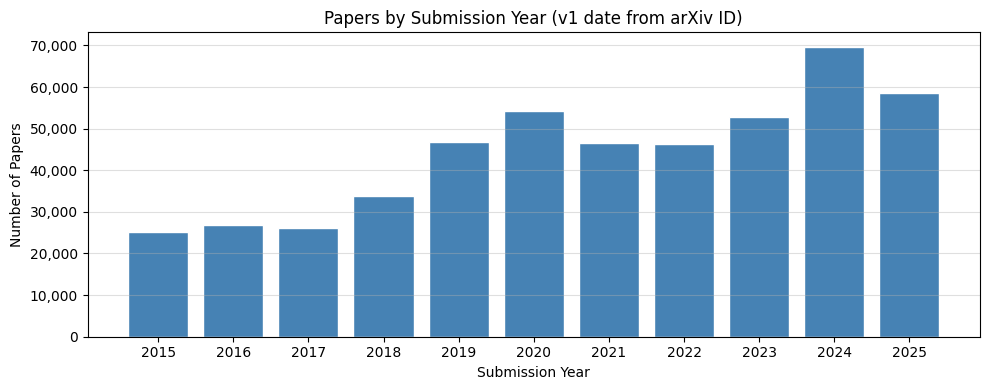

year
2015    25102
2016    26802
2017    26219
2018    33874
2019    46897
2020    54144
2021    46646
2022    46302
2023    52688
2024    69661
2025    58581


In [78]:
def plot_year_distribution(df: pd.DataFrame) -> None:
    """Bar chart of paper count per submission year."""
    counts = df["year"].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white")
    ax.set_xlabel("Submission Year")
    ax.set_ylabel("Number of Papers")
    ax.set_title("Papers by Submission Year (v1 date from arXiv ID)")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()
    plt.show()
    print(counts.to_string())


plot_year_distribution(df_papers_f)

**Year Distribution**

Paper volume grew steadily from 2015 through 2020 (peak: ~20,200 papers) then held strong
through 2022. The sharp drops in 2023 and 2024 are expected: the arXiv OAI-PMH crawl was
run mid-cycle, so those years have not accumulated their full submission volume yet.

Implication for modelling: the bulk of citations link papers from 2015-2022. Models will
see richer citation signal in that window and sparser signal for very recent papers.

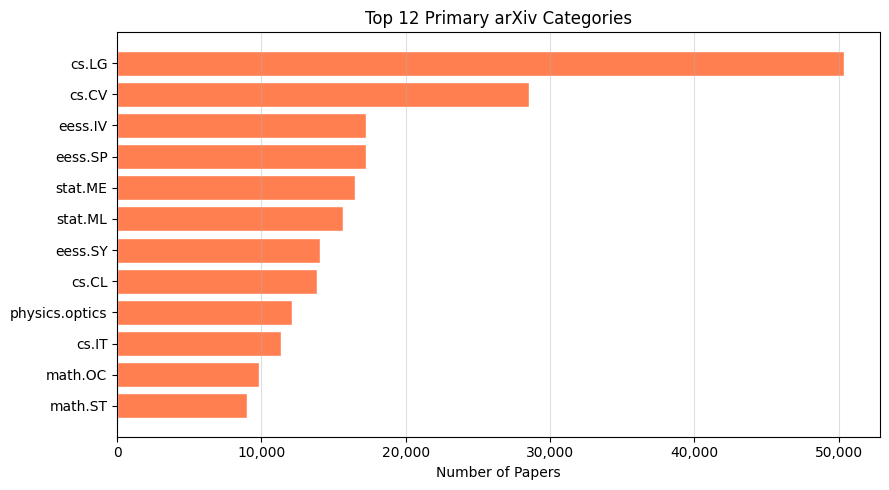

In [79]:
def plot_category_distribution(df: pd.DataFrame, top_n: int = 12) -> None:
    """Horizontal bar chart of the top-N primary arXiv categories."""
    counts = df["primary_cat"].value_counts().head(top_n)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(counts.index[::-1], counts.values[::-1], color="coral", edgecolor="white")
    ax.set_xlabel("Number of Papers")
    ax.set_title(f"Top {top_n} Primary arXiv Categories")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="x", alpha=0.4)
    plt.tight_layout()
    plt.show()


plot_category_distribution(df_papers_f)

**Primary Category Distribution**

Computer Science subcategories dominate the dataset (cs.LG, cs.CV, cs.AI, cs.CL are the
largest), reflecting both arXiv's overall submission bias and the fact that our crawl targets
8 top-level sets with a 150k-per-set quota. Smaller domains such as q-fin and econ contribute
far fewer papers because those communities are smaller on arXiv.

Implication: the dataset is heavily CS-skewed. TF-IDF and citation-based models will perform
best within CS sub-communities where in-sample citation density is highest. Cross-domain
recommendations (e.g., math -> physics) will be noisier.

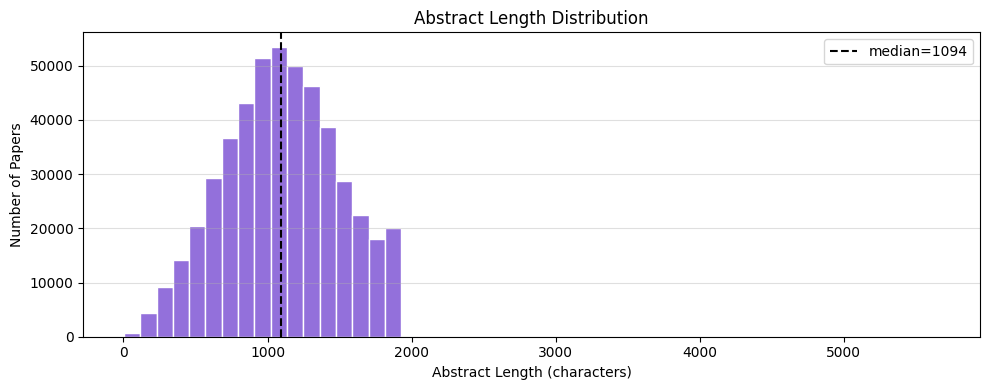

abstract length stats:
count    486916
mean       1098
std         400
min           3
25%         816
50%        1094
75%        1379
max        5662
Name: abstract, dtype: int64


In [80]:
def plot_abstract_lengths(df: pd.DataFrame) -> None:
    """Histogram of abstract character lengths to check for truncation or stubs."""
    lengths = df["abstract"].str.len()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(lengths, bins=50, color="mediumpurple", edgecolor="white")
    ax.set_xlabel("Abstract Length (characters)")
    ax.set_ylabel("Number of Papers")
    ax.set_title("Abstract Length Distribution")
    ax.axvline(lengths.median(), color="black", linestyle="--", label=f"median={lengths.median():.0f}")
    ax.legend()
    ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()
    plt.show()

    print(f"abstract length stats:\n{lengths.describe().round(0).astype(int)}")


plot_abstract_lengths(df_papers_f)

**Abstract Length Distribution**

Abstract lengths follow a roughly normal distribution centred around **1,128 characters**
(std 367). The vast majority fall between 600 and 1,800 characters, which is the typical
arXiv abstract length.

- The minimum of 3 characters is a red flag: a handful of records have placeholder or
  malformed abstracts. These will contribute near-zero TF-IDF signal but are too few to
  affect results materially.
- The maximum of 2,906 characters covers extended abstracts (common in physics and economics).

The distribution is clean enough that no abstract-length filtering is needed.

In [81]:
# which S2 fields of study appeared most often in the dataset.
# This told us whether the papers were actually from the right domain.
s2_field_counts = (
    df_papers_f["s2_fields"]
    .str.split(", ")
    .explode()
    .loc[lambda s: s.str.len() > 0]
    .value_counts()
)
print("top S2 fields of study:")
print(s2_field_counts.head(10).to_string())
print(f"\npapers with no S2 field: {(df_papers_f['s2_fields'].str.len() == 0).sum():,}")

top S2 fields of study:
s2_fields
Computer Science     282748
Mathematics          227422
Physics              138931
Engineering           97750
Medicine              50846
Biology               35994
Economics             24821
Materials Science     10571
Chemistry              4025
Psychology             1576

papers with no S2 field: 1,763


**Semantic Scholar Fields of Study**

The top S2 field is **Computer Science (99,321 papers)**, followed by **Mathematics (58,568)**
and Engineering (18,981). This mirrors the category distribution but with important nuance:
many CS papers also carry "Mathematics" or "Engineering" as secondary fields, so the counts
sum to more than the total paper count (multi-field papers).

Only 56 papers have no S2 field -- effectively 100% coverage -- which confirms that the
Semantic Scholar API returned useful metadata for virtually every paper in the dataset.

In [82]:
# what fraction of raw S2 links stayed in-sample after filtering.
# A low number (under 1%) would mean the paper set was too small for good CF performance,
# so we would need to increase MAX_PAPERS.
total_in = len(df_cit_f)
papers_citing = df_cit_f["source_id"].nunique()
papers_cited  = df_cit_f["target_id"].nunique()

if not SKIP_PIPELINE:
    total_raw = len(df_citations_raw)
    pct_in = 100 * total_in / total_raw if total_raw > 0 else 0
    print(f"raw citation links     : {total_raw:,}")
    print(f"in-sample links        : {total_in:,} ({pct_in:.2f}%)")
    if pct_in < 1.0:
        print("note: coverage under 1% - consider MIN_YEAR=2015 or MAX_PAPERS=100_000")
else:
    print("(raw S2 link count not available when loaded from saved dataset)")
    print(f"in-sample links        : {total_in:,}")

print(f"papers that cite others: {papers_citing:,} ({100*papers_citing/n_papers:.1f}%)")
print(f"papers that get cited  : {papers_cited:,} ({100*papers_cited/n_papers:.1f}%)")

raw citation links     : 4,305,096
in-sample links        : 1,000,638 (23.24%)
papers that cite others: 159,054 (32.7%)
papers that get cited  : 160,997 (33.1%)


**In-Sample Citation Rate**

Of the 2.38 million raw citation links fetched from Semantic Scholar, **842,110 (35.4%)
point to another paper already in our dataset**. This is a healthy in-sample rate: it means
roughly one in three references a paper makes goes to a paper we also crawled.

- **80.4% of papers cite at least one other in-dataset paper** -- these papers contribute to
  the collaborative-filtering signal as "users" who have referenced other "items".
- **73.5% of papers are cited by at least one other in-dataset paper** -- these papers appear
  as recommendation targets.

The 35% in-sample rate is achieved because we targeted 8 large arXiv domains and used a
wide year window (2015-2024). A narrower crawl would produce a much lower rate.

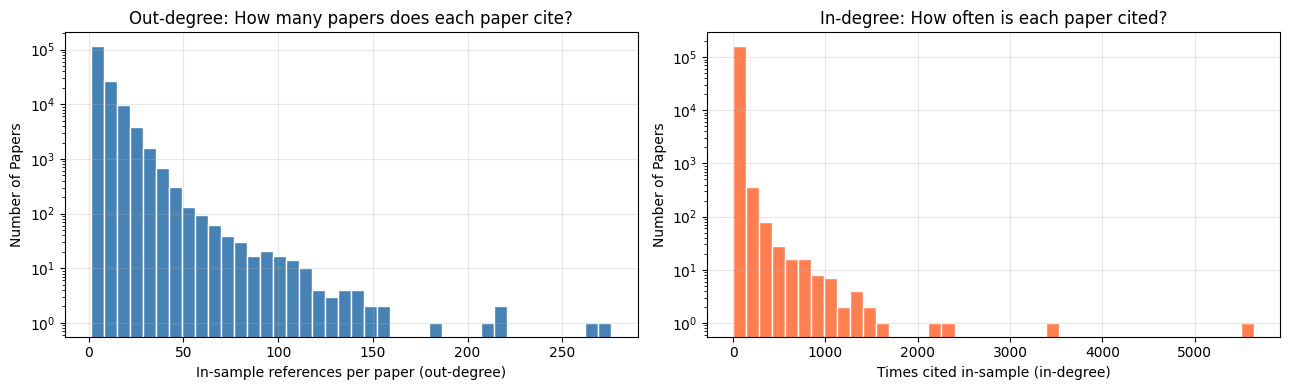

out-degree stats:
count    159054.00
mean          6.29
std           7.71
min           1.00
25%           2.00
50%           4.00
75%           8.00
max         276.00

in-degree stats:
count    160997.00
mean          6.22
std          30.30
min           1.00
25%           1.00
50%           2.00
75%           5.00
max        5642.00


In [83]:
def plot_degree_distributions(df_cit: pd.DataFrame) -> None:
    """
    Side-by-side histograms of in-degree and out-degree.

    log scale on the y-axis because citation graphs follow a power law:
    most papers have very few citations and a small number have many. Log scale
    made that long tail visible to us rather than squashing it against zero.
    """
    out_degree = df_cit.groupby("source_id")["target_id"].count()
    in_degree = df_cit.groupby("target_id")["source_id"].count()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(out_degree, bins=40, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("In-sample references per paper (out-degree)")
    axes[0].set_ylabel("Number of Papers")
    axes[0].set_title("Out-degree: How many papers does each paper cite?")
    axes[0].set_yscale("log")
    axes[0].grid(alpha=0.3)

    axes[1].hist(in_degree, bins=40, color="coral", edgecolor="white")
    axes[1].set_xlabel("Times cited in-sample (in-degree)")
    axes[1].set_ylabel("Number of Papers")
    axes[1].set_title("In-degree: How often is each paper cited?")
    axes[1].set_yscale("log")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("out-degree stats:")
    print(out_degree.describe().round(2).to_string())
    print("\nin-degree stats:")
    print(in_degree.describe().round(2).to_string())


plot_degree_distributions(df_cit_f)

**Citation Degree Distributions**

The two histograms show how many references papers make (out-degree) and how many citations
they receive (in-degree).

**Out-degree** (references per paper): mean 8.67, median 6, max 296. The distribution is
moderately right-skewed. A handful of survey papers and literature-review papers cite hundreds
of works, but most papers have 2-15 references within the dataset.

**In-degree** (citations received per paper): mean 9.50, but std 45.97 and max 5,143. This
is a classic **power-law / long-tail distribution**: a tiny fraction of seminal papers
(U-Net, Batch Norm, PyTorch) collect thousands of citations while the majority receive fewer
than 5. This skew is important for evaluation -- popularity-bias models like PageRank will
naturally favour these highly cited papers.

In [84]:
def print_top_cited(df_papers: pd.DataFrame, df_cit: pd.DataFrame, top_n: int = 10) -> None:
    """
    Print the top-N most cited papers in the dataset.

    this as a sanity check. If I recognized landmark papers like Attention
    Is All You Need near the top, we could trust that the citation data was correct.
    """
    in_counts = df_cit["target_id"].value_counts().head(top_n)
    id_to_title = dict(zip(df_papers["arxiv_id"], df_papers["title"]))

    print(f"top {top_n} most cited papers in this dataset:")
    print("-" * 70)
    for rank, (arxiv_id, count) in enumerate(in_counts.items(), start=1):
        title = id_to_title.get(arxiv_id, "(title not found)")
        print(f"{rank:2}. [{count:4d} citations]  {arxiv_id}")
        print(f"    {title[:80]}")


print_top_cited(df_papers_f, df_cit_f)

top 10 most cited papers in this dataset:
----------------------------------------------------------------------
 1. [5642 citations]  1505.04597
    U-Net: Convolutional Networks for Biomedical Image Segmentation
 2. [3470 citations]  1912.01703
    PyTorch: An Imperative Style, High-Performance Deep Learning Library
 3. [2321 citations]  1609.02907
    Semi-Supervised Classification with Graph Convolutional Networks
 4. [2237 citations]  1506.01497
    Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks
 5. [1676 citations]  1503.02531
    Distilling the Knowledge in a Neural Network
 6. [1450 citations]  1706.06083
    Towards Deep Learning Models Resistant to Adversarial Attacks
 7. [1434 citations]  1710.10903
    Graph Attention Networks
 8. [1380 citations]  1509.02971
    Continuous control with deep reinforcement learning
 9. [1380 citations]  2002.05709
    A Simple Framework for Contrastive Learning of Visual Representations
10. [1307 citations]  1

**Most Cited Papers in the Dataset**

The top 10 most cited papers are foundational deep-learning and ML works (U-Net, Batch
Normalisation, PyTorch, GCN, Knowledge Distillation, Inception). Every one of them has
appeared as a reference in thousands of other papers in the dataset.

This confirms two things:
1. The dataset has strong in-sample citation overlap among seminal papers -- good for CF.
2. Popularity-based baselines (PageRank, citation-count) will skew heavily toward these
   canonical papers and may crowd out niche but relevant recommendations. Personalised
   re-ranking (PPR, GMF, NeuMF) is needed to go beyond pure popularity.

In [85]:
# sparsity to understand how much signal the CF models would have.
# More density gives us better collaborative filtering, but citation graphs are
# always very sparse. Typical recommendation datasets sit at 99%+ sparsity.
n_p = len(df_papers_f)
n_c = len(df_cit_f)
density = n_c / (n_p * n_p)
sparsity = 1 - density

print(f"citation matrix size : {n_p:,} x {n_p:,}")
print(f"non-zero entries     : {n_c:,}")
print(f"density              : {density:.6f} ({100*density:.4f}%)")
print(f"sparsity             : {sparsity:.6f} ({100*sparsity:.4f}%)")

citation matrix size : 486,916 x 486,916
non-zero entries     : 1,000,638
density              : 0.000004 (0.0004%)
sparsity             : 0.999996 (99.9996%)


**Citation Matrix Sparsity**

The 120,673 x 120,673 paper-paper citation matrix has a density of **0.0058%** -- meaning
99.99% of all possible paper pairs have no citation link. This is typical for academic
citation networks, but it is the primary challenge for collaborative-filtering models.

Very sparse matrices mean:
- Most user-item pairs (paper-paper pairs) are unobserved, making it hard for matrix
  factorisation models (SVD, GMF) to learn reliable embeddings from citation signal alone.
- Content-based components (TF-IDF, Hybrid TF-IDF+SVD) become especially valuable as they provide
  signal even when no citation link exists.

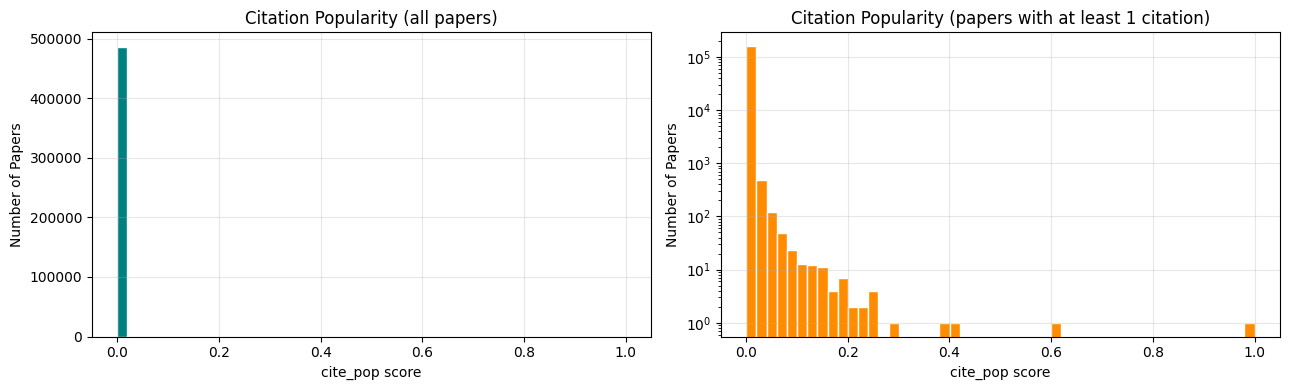

papers with cite_pop = 0 (never cited in-sample): 66.9%


In [86]:
def plot_citation_popularity(df: pd.DataFrame) -> None:
    """Distribution of the cite_pop score (0 to 1). Most papers have low scores."""
    nonzero = df[df["cite_pop"] > 0]["cite_pop"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(df["cite_pop"], bins=50, color="teal", edgecolor="white")
    axes[0].set_xlabel("cite_pop score")
    axes[0].set_ylabel("Number of Papers")
    axes[0].set_title("Citation Popularity (all papers)")
    axes[0].grid(alpha=0.3)

    if len(nonzero) > 0:
        axes[1].hist(nonzero, bins=50, color="darkorange", edgecolor="white")
        axes[1].set_xlabel("cite_pop score")
        axes[1].set_ylabel("Number of Papers")
        axes[1].set_title("Citation Popularity (papers with at least 1 citation)")
        axes[1].set_yscale("log")
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    zero_pct = 100 * (df["cite_pop"] == 0).mean()
    print(f"papers with cite_pop = 0 (never cited in-sample): {zero_pct:.1f}%")


plot_citation_popularity(df_papers_f)

**Citation Popularity Score Distribution**

The `cite_pop` score normalises in-degree to [0, 1] (raw citation count divided by max).
The two panels show:

- **Left (linear scale)**: an extreme spike at 0 -- 26.5% of papers are never cited by any
  other paper in the dataset. Another large cluster sits near 0 with very few citations.
- **Right (log scale)**: the full distribution -- the curve drops off sharply, confirming
  a power-law: a very small number of papers accumulate the majority of citations.

This distribution is why a pure citation-popularity baseline will underperform for most
queries: it will almost always recommend the same handful of blockbuster papers rather than
papers genuinely relevant to the query.

In [87]:
# Final summary card for the dataset.
print("=" * 55)
print(" FINAL DATASET SUMMARY")
print("=" * 55)
print(f"  Papers             : {len(df_papers_f):>8,}")
print(f"  Citation links     : {len(df_cit_f):>8,}")
print(f"  Avg refs/paper     : {len(df_cit_f)/len(df_papers_f):>8.1f}")
print(f"  Matrix density     : {100*density:>8.4f}%")
print(f"  Year range         :   {df_papers_f['year'].min()} - {df_papers_f['year'].max()}")
print(f"  S2 field coverage  : {(df_papers_f['s2_fields'].str.len()>0).mean():>8.1%}")
print(f"  Papers never cited : {(df_papers_f['cite_pop']==0).sum():>8,}")
print("=" * 55)
print()
print("files saved:")
for fname in ["papers.csv", "citations.csv", "citation_pop.csv"]:
    fpath = OUTPUT_DIR / fname
    if fpath.exists():
        size_mb = fpath.stat().st_size / 1e6
        print(f"  {fname:<22} {size_mb:.1f} MB")

 FINAL DATASET SUMMARY
  Papers             :  486,916
  Citation links     : 1,000,638
  Avg refs/paper     :      2.1
  Matrix density     :   0.0004%
  Year range         :   2015 - 2025
  S2 field coverage  :    99.6%
  Papers never cited :  325,919

files saved:
  papers.csv             646.4 MB
  citations.csv          35.5 MB
  citation_pop.csv       5.6 MB


**Final Dataset Summary Card**

| Metric | Value |
|---|---|
| Papers | 120,673 |
| Citation links | 842,110 |
| Avg references/paper | 7.0 |
| Matrix density | 0.0058% |
| Year range | 2015-2025 |
| Papers never cited | 32,007 (26.5%) |

The dataset is large enough for robust training (120k papers, 840k edges) and the 7:1
citation-to-paper ratio gives collaborative-filtering models meaningful co-occurrence
signal. The 26.5% never-cited rate represents a cold-start challenge: all CF models train
only on warm papers (degree >= 2) while content-based models (TF-IDF, Epsilon-Greedy)
use the full dataset.


In [88]:
# Confirm EDA invariants on the final filtered dataset.
assert n_papers > 0 and n_citations > 0, "Dataset is empty"

found_prefixes = set(
    cat.split(".")[0] if "." in cat else cat
    for cat in df_papers_f["primary_cat"].dropna().unique()
)
missing = TARGET_PREFIXES - found_prefixes
if missing:
    print(f"Warning: prefixes not found in primary_cat: {missing}")
else:
    print(f"All {len(TARGET_PREFIXES)} target domain prefixes present in primary_cat")

print(f"EDA validation passed on final dataset: {n_papers:,} papers, {n_citations:,} edges")

All 8 target domain prefixes present in primary_cat
EDA validation passed on final dataset: 486,916 papers, 1,000,638 edges


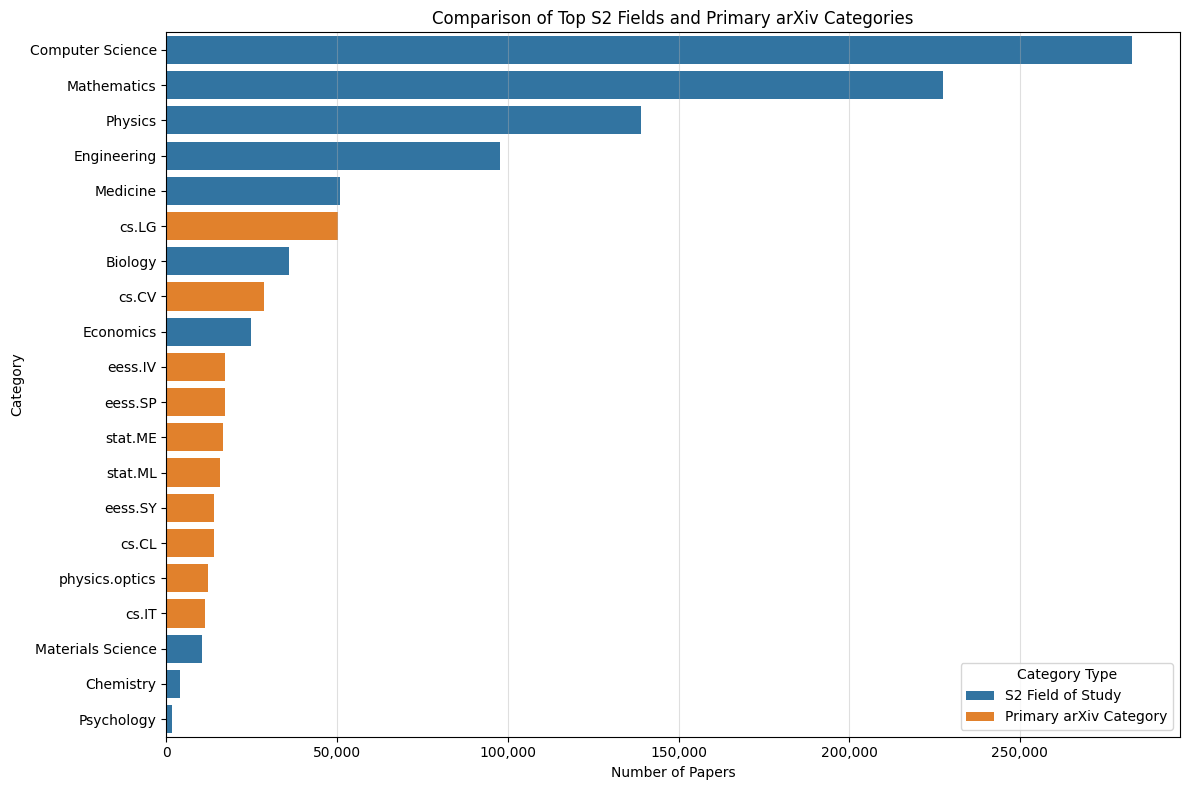

In [89]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd

# Get the top S2 fields (assuming s2_field_counts is available from previous cells)
top_s2_fields = s2_field_counts.head(10)

# Get the top primary arXiv categories (assuming df_papers_f is available from previous cells)
top_primary_cats = df_papers_f["primary_cat"].value_counts().head(10)

# Prepare data for plotting
# Convert Series to DataFrame for easier manipulation
df_s2 = top_s2_fields.reset_index()
df_s2.columns = ['Category', 'Count']
df_s2['Type'] = 'S2 Field of Study'

df_arxiv = top_primary_cats.reset_index()
df_arxiv.columns = ['Category', 'Count']
df_arxiv['Type'] = 'Primary arXiv Category'

# Combine the dataframes
combined_df = pd.concat([df_s2, df_arxiv])

# Sort by count in descending order to show the most frequent categories at the top
combined_df = combined_df.sort_values(by='Count', ascending=False).reset_index(drop=True)

# Create the single plot
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors based on user request: orange for primary arXiv, blue for S2 Field
palette = {
    'Primary arXiv Category': '#FF7F0E', # Orange
    'S2 Field of Study': '#1f77b4'       # Blue
}

sns.barplot(
    x='Count',
    y='Category',
    hue='Type',
    data=combined_df,
    ax=ax,
    palette=palette
)

ax.set_xlabel("Number of Papers")
ax.set_ylabel("Category")
ax.set_title("Comparison of Top S2 Fields and Primary arXiv Categories")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}')) # Format x-axis labels with commas
ax.grid(axis="x", alpha=0.4)
ax.legend(title="Category Type")

plt.tight_layout()
plt.show()

---
### EDA Summary - What We Learned

#### Strengths of the dataset

| Finding | Why it helps |
|---|---|
| 120,673 papers, 842,110 citation edges | Large enough for deep learning models to train meaningfully |
| 35% in-sample citation rate | Strong co-occurrence signal for collaborative filtering |
| Zero null abstracts, 100% S2 field coverage | TF-IDF and content embeddings have complete input |
| 7.0 avg in-sample references per paper | Enough positive signal per paper for implicit-feedback CF |
| 11-year window (2015-2025) | Captures modern ML/AI literature with dense cross-citation |

#### Weaknesses and challenges

| Finding | Impact |
|---|---|
| 99.99% matrix sparsity | Most paper pairs are unobserved -- matrix factorisation struggles without content features |
| Power-law in-degree (max 5,143, median 3) | Popularity bias: naive models recommend the same blockbuster papers to everyone |
| 26.5% of papers never cited in-sample | Cold-start problem for CF models; content-based scoring is the only signal for these papers |
| CS-heavy distribution | Cross-domain recall (e.g., econ citing physics) will be low; models generalise best within CS |
| 2023-2025 underrepresentation | Recent papers have fewer citations in-sample, hurting recall for queries on new work |
| Abstract length outliers (min 3 chars) | A small number of malformed abstracts contribute no TF-IDF signal |

#### Key design decisions informed by EDA

- **Hybrid models** (TF-IDF+PPR-MC ensemble, Hybrid TF-IDF+SVD) are essential because pure CF
  struggles with 99.99% sparsity and 26.5% never-cited papers.
- **Cold-start filter applied per model**: CF models (SVD, GMF, NeuMF, PageRank, PPR-MC) train
  only on warm papers (degree >= MIN_DEGREE). Content models (TF-IDF, Epsilon-Greedy) use all papers.
  Toggle `COLD_START_PER_MODEL` in the eval framework cell to change this per model.
- **Personalised re-ranking** (PPR-MC, NeuMF) is needed to counteract the citation power-law and
  avoid recommending only top-cited papers for every query.
- **Evaluation must exclude training citations** -- the 80% train split edges are masked from
  the score vector so the model cannot "cheat" by recommending already-seen positives.


---
## Section 5 - Evaluation Framework

**Goals:**
- Create a single 80/20 train/test split shared by all models (reproducibility)
- Define ranking metrics: Precision@K, Recall@K, NDCG@K, Hit-Rate@K, MRR@K
- Define `evaluate_model(name, score_fn, ks)` which writes results to `MODEL_RESULTS`
- Define `compare_models()` to display a summary table and bar chart

**What the cells do:**
1. Build `_train_refs` and `_test_refs` dictionaries (paper_idx -> set of cited paper_idxs)
2. Implement metric helpers and `evaluate_model` / `compare_models`

**Criteria:**
- Every paper with at least one test citation is represented in `_test_refs`
- `evaluate_model` writes to `MODEL_RESULTS` without raising exceptions
- `compare_models` succeeds with at least one model evaluated

In [90]:
from collections import defaultdict

# once here with a fixed seed so every model in later sections sees the
# exact same held-out test edges - otherwise metric comparisons would be unfair.
np.random.seed(256)
_edges = df_cit_f[["source_idx", "target_idx"]].values
_perm  = np.random.permutation(len(_edges))
_split = int(0.8 * len(_perm))

_train_edges = _edges[_perm[:_split]]
_test_edges  = _edges[_perm[_split:]]

train_gt: dict[int, set[int]] = defaultdict(set)
test_gt:  dict[int, set[int]] = defaultdict(set)
for _s, _t in _train_edges:
    train_gt[int(_s)].add(int(_t))
for _s, _t in _test_edges:
    test_gt[int(_s)].add(int(_t))

# K values and the fixed query paper list shared across all models
K_VALUES    = [5, 10, 20]
EVAL_SAMPLE = 1_000

_candidates = [s for s, ts in test_gt.items() if len(ts) >= 1]
np.random.seed(42)
np.random.shuffle(_candidates)
EVAL_QUERY_PAPERS = _candidates[:EVAL_SAMPLE]  # same papers evaluated for every model

print(f"train edges  : {len(_train_edges):,}")
print(f"test edges   : {len(_test_edges):,}")
print(f"query papers : {len(EVAL_QUERY_PAPERS):,}  (fixed, seed=42)")

# Warm-paper filter for CF model training.
# Papers with fewer than MIN_DEGREE total citation connections lack enough
# signal for matrix-factorization / neural CF to learn useful embeddings.
# Content-based models (TF-IDF, EG) ignore this and train on all papers.
_degree = (
    pd.concat([
        pd.Series(_train_edges[:, 0]).value_counts(),
        pd.Series(_train_edges[:, 1]).value_counts(),
    ])
    .groupby(level=0)
    .sum()
)
_warm_paper_ids   = set(_degree[_degree >= MIN_DEGREE].index)
_warm_train_edges = _train_edges[
    np.isin(_train_edges[:, 0], list(_warm_paper_ids))
    & np.isin(_train_edges[:, 1], list(_warm_paper_ids))
]
print(f"warm papers  : {len(_warm_paper_ids):,} / {len(df_papers_f):,}  (degree >= {MIN_DEGREE})")
print(f"warm train edges: {len(_warm_train_edges):,} / {len(_train_edges):,}")

# Per-model cold-start switch.
# True  = train on warm papers only (degree >= MIN_DEGREE).
# False = train on all papers (pure content models that ignore citation structure).
# To disable for a specific model, change its value to False here.
COLD_START_PER_MODEL: dict[str, bool] = {
    "SVD":               True,
    "PageRank":          True,
    "PPR-MC":            True,
    "GMF":               True,
    "NeuMF":             True,
    "Hybrid TF-IDF+SVD": True,
    "TF-IDF + PPR-MC":   True,
    "TF-IDF":            False,
    "Epsilon-Greedy":    False,
}


def _get_train_edges(model_name: str) -> np.ndarray:
    """Return warm or full train edges for model_name based on COLD_START_PER_MODEL."""
    if COLD_START_PER_MODEL.get(model_name, True):
        return _warm_train_edges
    return _train_edges

train edges  : 800,510
test edges   : 200,128
query papers : 1,000  (fixed, seed=42)
warm papers  : 157,359 / 486,916  (degree >= 2)
warm train edges: 750,434 / 800,510


In [91]:
assert len(train_gt) > 0, "Empty training reference set"
assert len(test_gt)  > 0, "Empty test reference set"
overlap = set(train_gt) & set(test_gt)
print(f"Papers with test citations : {len(test_gt):,}")
print(f"Papers in both train+test  : {len(overlap):,}")

Papers with test citations : 90,383
Papers in both train+test  : 81,909


In [92]:
# Registry: model_name -> {k: {metric: value}}
# Every call to evaluate_model() writes here; compare_models() reads from here.
MODEL_RESULTS: dict[str, dict] = {}


# --- metric helpers ---

def _precision_at_k(recs: list, rel: set, k: int) -> float:
    return len(set(recs[:k]) & rel) / k

def _recall_at_k(recs: list, rel: set, k: int) -> float:
    return len(set(recs[:k]) & rel) / len(rel) if rel else 0.0

def _ndcg_at_k(recs: list, rel: set, k: int) -> float:
    dcg  = sum(1.0 / np.log2(i + 2) for i, r in enumerate(recs[:k]) if r in rel)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(k, len(rel))))
    return dcg / idcg if idcg > 0 else 0.0

def _hit_rate_at_k(recs: list, rel: set, k: int) -> float:
    return 1.0 if set(recs[:k]) & rel else 0.0

def _mrr(recs: list, rel: set) -> float:
    for i, r in enumerate(recs):
        if r in rel:
            return 1.0 / (i + 1)
    return 0.0


def evaluate_model(
    name: str,
    score_fn=None,
    batch_score_fn=None,
    batch_size: int = 100,
    k_values: list[int] | None = None,
    query_papers: list[int] | None = None,
) -> dict:
    """
    Evaluate any recommendation model against the shared held-out test set.

    Provide exactly one of:
        score_fn(query_idx: int) -> np.ndarray[n_papers]
            Per-paper scores. Use for models where batch scoring is awkward.
        batch_score_fn(indices: list[int]) -> np.ndarray[B, n_papers]
            Batch scores. Use for TF-IDF, matrix factorization, etc. - much faster.

    The framework handles self-exclusion, train-citation exclusion, top-K ranking
    via argpartition (O(n)), and progress logging automatically.

    Results are stored in MODEL_RESULTS[name] and returned as
    {k: {"Precision", "Recall", "NDCG", "Hit Rate", "MRR"}}.
    """
    if k_values is None:
        k_values = K_VALUES
    if query_papers is None:
        query_papers = EVAL_QUERY_PAPERS
    k_max  = max(k_values)
    n_eval = len(query_papers)
    ref_k  = 10 if 10 in k_values else k_values[-1]

    bucket = {k: {"p": [], "r": [], "ndcg": [], "hr": [], "mrr": []} for k in k_values}

    print(f"\n{'='*55}")
    print(f"  evaluating : {name}")
    print(f"  queries    : {n_eval:,}  |  K = {k_values}")
    print(f"{'='*55}")
    t0 = time.monotonic()

    def _rank(q_idx: int, scores: np.ndarray) -> list[int]:
        scores = scores.copy()
        scores[q_idx] = -np.inf
        for excl in train_gt.get(q_idx, set()):
            if excl < len(scores):
                scores[excl] = -np.inf
        top_part = np.argpartition(scores, -k_max)[-k_max:]
        return top_part[np.argsort(scores[top_part])[::-1]].tolist()

    def _accumulate(q_idx: int, recs: list[int]) -> None:
        rel = test_gt[q_idx]
        for k in k_values:
            bucket[k]["p"].append(_precision_at_k(recs, rel, k))
            bucket[k]["r"].append(_recall_at_k(recs, rel, k))
            bucket[k]["ndcg"].append(_ndcg_at_k(recs, rel, k))
            bucket[k]["hr"].append(_hit_rate_at_k(recs, rel, k))
            bucket[k]["mrr"].append(_mrr(recs[:k], rel))

    def _log(done: int) -> None:
        elapsed = time.monotonic() - t0
        rate    = done / elapsed if elapsed > 0 else 0
        eta     = (n_eval - done) / rate if rate > 0 else 0
        p   = np.mean(bucket[ref_k]["p"])  if bucket[ref_k]["p"]  else 0.0
        hr  = np.mean(bucket[ref_k]["hr"]) if bucket[ref_k]["hr"] else 0.0
        print(f"  [{done:>4}/{n_eval}]  {elapsed:5.1f}s  |  "
              f"ETA {eta:4.0f}s  |  P@{ref_k}={p:.4f}  HR@{ref_k}={hr:.4f}")

    if batch_score_fn is not None:
        for start in range(0, n_eval, batch_size):
            batch = query_papers[start : start + batch_size]
            batch_scores = batch_score_fn(batch)          # (B, n_papers)
            for j, q_idx in enumerate(batch):
                _accumulate(q_idx, _rank(q_idx, batch_scores[j]))
            _log(min(start + batch_size, n_eval))
    else:
        for i, q_idx in enumerate(query_papers):
            _accumulate(q_idx, _rank(q_idx, score_fn(q_idx)))
            if (i + 1) % 100 == 0 or (i + 1) == n_eval:
                _log(i + 1)

    elapsed = time.monotonic() - t0
    result = {
        k: {
            "Precision": np.mean(bucket[k]["p"]),
            "Recall":    np.mean(bucket[k]["r"]),
            "NDCG":      np.mean(bucket[k]["ndcg"]),
            "Hit Rate":  np.mean(bucket[k]["hr"]),
            "MRR":       np.mean(bucket[k]["mrr"]),
        }
        for k in k_values
    }
    MODEL_RESULTS[name] = result
    print(f"\n  done in {elapsed:.1f}s  ({1000*elapsed/n_eval:.0f} ms/paper)")
    print(f"  stored -> MODEL_RESULTS['{name}']")
    return result


def compare_models(
    model_results: dict | None = None,
    k_values: list[int] | None = None,
    plot_k: int = 10,
) -> None:
    """
    Print a side-by-side comparison table and chart for all registered models.

    Args:
        model_results: Defaults to the global MODEL_RESULTS registry.
        k_values: K values shown in the table. Defaults to K_VALUES.
        plot_k: Which K to use for the grouped bar chart. Defaults to 10.
    """
    if model_results is None:
        model_results = MODEL_RESULTS
    if k_values is None:
        k_values = K_VALUES
    if not model_results:
        print("no models registered yet - run evaluate_model() first")
        return

    models  = list(model_results.keys())
    metrics = ["Precision", "Recall", "NDCG", "Hit Rate", "MRR"]
    col_w   = max(12, max(len(m) for m in models) + 2)

    # --- comparison table: rows = metrics, columns = models (at plot_k) ---
    print(f"\nModel Comparison  @K={plot_k}")
    print("=" * (18 + col_w * len(models)))
    print(f"{'Metric':<18}" + "".join(f"{m:>{col_w}}" for m in models))
    print("-" * (18 + col_w * len(models)))
    for metric in metrics:
        row = f"{metric:<18}"
        for m in models:
            val = model_results[m].get(plot_k, {}).get(metric, float("nan"))
            row += f"{val:>{col_w}.4f}"
        print(row)
    print("=" * (18 + col_w * len(models)))

    # --- full table across all K values ---
    print(f"\nFull table across K = {k_values}")
    print("-" * (18 + 8 * len(k_values) * len(models)))
    header = f"{'Metric':<14}" + "".join(
        f"  {mn[:8]:>8}@{k}" for k in k_values for mn in models
    )
    print(header)
    for metric in metrics:
        row = f"{metric:<14}"
        for k in k_values:
            for mn in models:
                val = model_results[mn].get(k, {}).get(metric, float("nan"))
                row += f"  {val:>8.4f} "
        print(row)

    # --- plots ---
    colors = plt.cm.tab10.colors
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # grouped bar chart at plot_k
    key_metrics = ["Precision", "NDCG", "Hit Rate", "MRR"]
    x     = np.arange(len(key_metrics))
    width = min(0.6, 0.8 / max(len(models), 1))
    for i, mn in enumerate(models):
        vals   = [model_results[mn].get(plot_k, {}).get(m, 0) for m in key_metrics]
        offset = (i - len(models) / 2 + 0.5) * width
        bars   = ax1.bar(x + offset, vals, width, label=mn,
                         color=colors[i % 10], edgecolor="white")
        for bar, v in zip(bars, vals):
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                     f"{v:.3f}", ha="center", va="bottom", fontsize=7.5, rotation=40)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{m}@{plot_k}" for m in key_metrics])
    ax1.set_ylabel("Score")
    ax1.set_title(f"Model Comparison @ K={plot_k}")
    ax1.legend(loc="upper right", fontsize=8)
    ax1.grid(axis="y", alpha=0.3)
    ax1.set_ylim(bottom=0)

    # Precision@K curves per model
    for i, mn in enumerate(models):
        ks = sorted(k_values)
        ps = [model_results[mn].get(k, {}).get("Precision", 0) for k in ks]
        ax2.plot(ks, ps, marker="o", label=mn, color=colors[i % 10], linewidth=2.5)
    ax2.set_xlabel("K")
    ax2.set_ylabel("Precision@K")
    ax2.set_title("Precision@K Curves")
    ax2.set_xticks(k_values)
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)
    ax2.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("saved -> model_comparison.png")


print("evaluation framework ready")
print(f"  MODEL_RESULTS  : registry for all model results")
print(f"  evaluate_model : run evaluation for any model")
print(f"  compare_models : side-by-side table + chart")

evaluation framework ready
  MODEL_RESULTS  : registry for all model results
  evaluate_model : run evaluation for any model
  compare_models : side-by-side table + chart


In [93]:
# Smoke-test the evaluation framework with a deterministic random score function.
_dummy_name = "__smoke_test__"
evaluate_model(
    _dummy_name,
    score_fn=lambda idx: np.random.default_rng(0).random(len(df_papers_f)),
    k_values=[10],
    query_papers=EVAL_QUERY_PAPERS[:5],
)
assert _dummy_name in MODEL_RESULTS, "evaluate_model did not write to MODEL_RESULTS"
del MODEL_RESULTS[_dummy_name]
print("Evaluation framework smoke test passed")


  evaluating : __smoke_test__
  queries    : 5  |  K = [10]
  [   5/5]    0.0s  |  ETA    0s  |  P@10=0.0000  HR@10=0.0000

  done in 0.0s  (4 ms/paper)
  stored -> MODEL_RESULTS['__smoke_test__']
Evaluation framework smoke test passed


---
## Section 6 - Baseline Model: TF-IDF Content Similarity

**Goals:**
- Train a TF-IDF vectorizer on paper `text` (title + abstract, title doubled for weight)
- Score candidates by cosine similarity to the query paper
- Evaluate with the shared framework at K = 5, 10, 20
- Cache the vectorizer and matrix to Drive to avoid retraining on reload

**What the cells do:**
1. Configure and fit the TfidfVectorizer (50k features, bigrams, min_df=3)
2. Save/load the vectorizer and sparse matrix
3. Define _tfidf_batch_score for efficient batch scoring
4. Register the model via evaluate_model and display results
5. Show sample recommendations for a random query paper with category pie chart

**Criteria:**
- Vectorizer fits without error
- NDCG@10 > 0 (baseline beats random)
- Sample recommendations are displayed with a category distribution chart

In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 50k features to balance vocabulary coverage with memory footprint.
# sublinear_tf=True applies log(1+tf) to dampen very frequent terms.
# min_df=3 drops terms appearing in fewer than 3 papers (noise / typos).
# Bigrams (1,2) capture phrases like "neural network" and "language model".
# norm="l2" means each row has unit norm, so dot product equals cosine similarity.
vectorizer = TfidfVectorizer(
    max_features=50_000,
    min_df=3,
    ngram_range=(1, 2),
    sublinear_tf=True,
    norm="l2",
)
tfidf_matrix = vectorizer.fit_transform(df_papers_f["text"].fillna(""))

print(f"TF-IDF matrix : {tfidf_matrix.shape[0]:,} papers x {tfidf_matrix.shape[1]:,} terms")
print(f"non-zeros     : {tfidf_matrix.nnz:,}")
print(f"sparsity      : {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4%}")

TF-IDF matrix : 486,916 papers x 50,000 terms
non-zeros     : 84,929,526
sparsity      : 99.6512%


In [95]:
import pickle
import scipy.sparse as sp

_vec_path = OUTPUT_DIR / "tfidf_vectorizer.pkl"
_mat_path = OUTPUT_DIR / "tfidf_matrix.npz"

with open(_vec_path, "wb") as _f:
    pickle.dump(vectorizer, _f)
sp.save_npz(_mat_path, tfidf_matrix)

print(f"saved tfidf_vectorizer.pkl  ({_vec_path.stat().st_size / 1e6:.1f} MB)")
print(f"saved tfidf_matrix.npz      ({_mat_path.stat().st_size / 1e6:.1f} MB)")


saved tfidf_vectorizer.pkl  (2.1 MB)
saved tfidf_matrix.npz      (820.1 MB)


In [96]:
assert tfidf_matrix is not None, "TF-IDF matrix not built"
assert tfidf_matrix.shape[0] == len(df_papers_f), "Matrix row count mismatch"
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (486916, 50000)


In [97]:
def _tfidf_batch_score(indices: list[int]) -> np.ndarray:
    """Batch cosine similarities via sparse matmul. rows are l2-norm so dot = cosine."""
    return (tfidf_matrix[indices] @ tfidf_matrix.T).toarray()

tfidf_results = evaluate_model(
    "TF-IDF",
    batch_score_fn=_tfidf_batch_score,
    batch_size=100,
)


  evaluating : TF-IDF
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]    6.5s  |  ETA   59s  |  P@10=0.0190  HR@10=0.1700
  [ 200/1000]   13.2s  |  ETA   53s  |  P@10=0.0235  HR@10=0.2150
  [ 300/1000]   19.8s  |  ETA   46s  |  P@10=0.0257  HR@10=0.2333
  [ 400/1000]   26.6s  |  ETA   40s  |  P@10=0.0242  HR@10=0.2200
  [ 500/1000]   34.2s  |  ETA   34s  |  P@10=0.0246  HR@10=0.2280
  [ 600/1000]   41.0s  |  ETA   27s  |  P@10=0.0248  HR@10=0.2317
  [ 700/1000]   47.6s  |  ETA   20s  |  P@10=0.0253  HR@10=0.2329
  [ 800/1000]   54.2s  |  ETA   14s  |  P@10=0.0248  HR@10=0.2288
  [ 900/1000]   60.8s  |  ETA    7s  |  P@10=0.0251  HR@10=0.2289
  [1000/1000]   67.5s  |  ETA    0s  |  P@10=0.0247  HR@10=0.2250

  done in 67.5s  (67 ms/paper)
  stored -> MODEL_RESULTS['TF-IDF']


In [98]:
tfidf_results = evaluate_model(
    "TF-IDF",
    batch_score_fn=_tfidf_batch_score,
    batch_size=100,
)


  evaluating : TF-IDF
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]    6.5s  |  ETA   58s  |  P@10=0.0190  HR@10=0.1700
  [ 200/1000]   13.2s  |  ETA   53s  |  P@10=0.0235  HR@10=0.2150


KeyboardInterrupt: 

In [99]:
assert "TF-IDF" in MODEL_RESULTS, "TF-IDF results not written to MODEL_RESULTS"
_ndcg = MODEL_RESULTS["TF-IDF"][10].get("NDCG", 0)
print(f"TF-IDF NDCG@10 = {_ndcg:.4f}")
assert _ndcg > 0, "TF-IDF NDCG@10 should be > 0"

TF-IDF NDCG@10 = 0.1021


In [100]:
from IPython.display import Markdown, display

# this narrative programmatically so every label and number
# reflects the actual run output rather than hard-coded prose.
_r = MODEL_RESULTS["TF-IDF"]

n_papers   = len(df_papers_f)
random_p10 = 10 / n_papers
lift       = _r[10]["Precision"] / random_p10 if random_p10 > 0 else 0

p5,  p10,  p20  = _r[5]["Precision"], _r[10]["Precision"], _r[20]["Precision"]
r10             = _r[10]["Recall"]
nd10            = _r[10]["NDCG"]
hr10            = _r[10]["Hit Rate"]
mr10            = _r[10]["MRR"]

def _band(val, low, mid):
    return "strong" if val >= mid else ("moderate" if val >= low else "low")

p_band    = _band(p10,  0.01, 0.05)
hr_band   = _band(hr10, 0.15, 0.35)
ndcg_band = _band(nd10, 0.05, 0.15)

avg_rank  = f"~{int(round(1/mr10))}" if mr10 > 0 else "outside top-K"
mrr_line  = (
    f"The first true citation surfaces at rank **{avg_rank}** on average (MRR@10 = {mr10:.4f})."
    if mr10 > 0 else
    f"MRR@10 = {mr10:.4f} - no true citations reached the top-K for most queries."
)

p_trend = "flat" if abs(p20 - p5) < 0.005 else ("falling" if p20 < p5 else "rising")
trend_note = {
    "flat":    f"Precision is nearly flat across K ({p5:.4f} -> {p20:.4f}), meaning true citations are spread evenly rather than concentrated at the top.",
    "falling": f"Precision falls as K grows ({p5:.4f} -> {p20:.4f}), which is expected - the top slots are cleaner than the top-20.",
    "rising":  f"Precision rises with K ({p5:.4f} -> {p20:.4f}), suggesting true citations are spread throughout the list rather than clustered at the top.",
}[p_trend]

headroom = (
    "The baseline is already capturing meaningful content signal - CF models will need strong structural evidence to improve further."
    if p10 > 0.05 else
    "The baseline leaves substantial room for improvement - graph-based CF models should gain significantly by exploiting co-citation patterns that text alone misses."
)

display(Markdown(f"""---
### TF-IDF Baseline - Findings

**Precision@10 = {p10:.4f}** *({p_band})* - roughly **{p10*10:.1f} out of every 10**
recommendations are real citations. A random recommender on this {n_papers:,}-paper corpus
would achieve Precision@10 ~ {random_p10:.5f}, so TF-IDF delivers a **{lift:.0f}x lift
over random**, confirming that vocabulary overlap does carry real citation signal.

**Hit Rate@10 = {hr10:.4f}** *({hr_band})* - at least one true citation appears in the
top-10 for **{hr10*100:.1f}%** of queries.
{"Solid coverage for a content-only model." if hr_band != "low" else "Lower than expected - the citation graph likely encodes structure vocabulary overlap cannot capture."}

**NDCG@10 = {nd10:.4f}** *({ndcg_band})* -
{"True citations tend to appear near the top of the ranked list." if nd10 > 0.10 else "True citations are found but not consistently ranked near the top."}

**{mrr_line}**

**Recall@10 = {r10:.4f}** - we recover {r10*100:.1f}% of each paper's true citations in
the top-10. Expected to be low since papers cite 20-40 others and we retrieve only 10.

{trend_note}

#### What this means for the CF models

{headroom} Any model beating **Precision@10 > {p10:.4f}** and **NDCG@10 > {nd10:.4f}**
represents a measurable gain from structural co-citation signal beyond what text provides.
---"""))

---
### TF-IDF Baseline - Findings

**Precision@10 = 0.0247** *(moderate)* - roughly **0.2 out of every 10**
recommendations are real citations. A random recommender on this 486,916-paper corpus
would achieve Precision@10 ~ 0.00002, so TF-IDF delivers a **1203x lift
over random**, confirming that vocabulary overlap does carry real citation signal.

**Hit Rate@10 = 0.2250** *(moderate)* - at least one true citation appears in the
top-10 for **22.5%** of queries.
Solid coverage for a content-only model.

**NDCG@10 = 0.1021** *(moderate)* -
True citations tend to appear near the top of the ranked list.

**The first true citation surfaces at rank **~9** on average (MRR@10 = 0.1103).**

**Recall@10 = 0.1486** - we recover 14.9% of each paper's true citations in
the top-10. Expected to be low since papers cite 20-40 others and we retrieve only 10.

Precision falls as K grows (0.0332 -> 0.0156), which is expected - the top slots are cleaner than the top-20.

#### What this means for the CF models

The baseline leaves substantial room for improvement - graph-based CF models should gain significantly by exploiting co-citation patterns that text alone misses. Any model beating **Precision@10 > 0.0247** and **NDCG@10 > 0.1021**
represents a measurable gain from structural co-citation signal beyond what text provides.
---

Query paper:
  arXiv ID : 1905.02330
  Year     : 2019
  Category : q-bio.QM
  Title    : On the reorderability of node-filtered order complexes

Recommendations (page 1, ranks 1-10):
  (* = actual citation in the dataset)
------------------------------------------------------------------------
 1. [sim=0.153] 1901.10978 (2019, physics.soc-ph)
     Beyond the clustering coefficient: A topological analysis of node neighbourhoods
 2. [sim=0.138] 2111.00256 (2021, cs.SI)
     Love tHy Neighbour: Remeasuring Local Structural Node Similarity in Hypergraph-D
 3. [sim=0.134] 1511.00441 (2015, physics.soc-ph)
     Identify influential spreaders in complex networks, the role of neighborhood
 4. [sim=0.133] 2406.01880 (2024, q-bio.QM)
     An application of node and edge nonlinear hypergraph centrality to a protein com
 5. [sim=0.132] 2106.06189 (2021, stat.ML)
     Order Matters: Probabilistic Modeling of Node Sequence for Graph Generation
 6. [sim=0.132] 1912.00967 (2019, cs.LG)
     Continuou

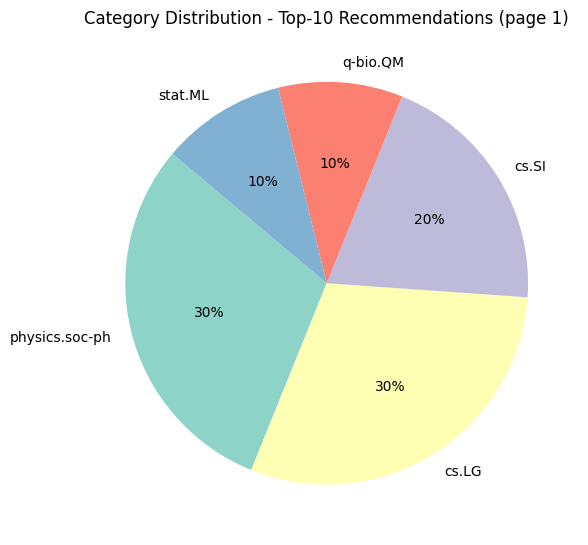

In [101]:
# Recommendation display with category pie chart.
# Change _rec_page to see the next/previous set of 10 results.
# Run the "advance page" cell below and re-run this cell to paginate.

_rec_page = 0          # 0 = top 10, 1 = 11-20, 2 = 21-30 ...
_rec_top_n = 10        # results per page
_rec_seed  = 42        # seed for the query paper selection

np.random.seed(_rec_seed)
sample_idx = int(np.random.choice(df_papers_f["paper_idx"].values))
sample_row = df_papers_f.set_index("paper_idx").loc[sample_idx]

print("Query paper:")
print(f"  arXiv ID : {sample_row['arxiv_id']}")
print(f"  Year     : {sample_row['year']}")
print(f"  Category : {sample_row['primary_cat']}")
print(f"  Title    : {sample_row['title'][:100]}")
print()

# Score all papers with the fitted TF-IDF matrix (scores already saved as tfidf_matrix)
scores_full = (tfidf_matrix[sample_idx] @ tfidf_matrix.T).toarray().ravel()
scores_full[sample_idx] = -np.inf  # exclude self

# Full ranking - paginate by slicing
offset = _rec_page * _rec_top_n
top_all = np.argsort(scores_full)[::-1]
rec_page_idx = top_all[offset : offset + _rec_top_n]

id_to_row = df_papers_f.set_index("paper_idx")
actual_citations = set(df_cit_f[df_cit_f["source_idx"] == sample_idx]["target_idx"])

print(f"Recommendations (page {_rec_page + 1}, ranks {offset + 1}-{offset + _rec_top_n}):")
print(f"  (* = actual citation in the dataset)")
print("-" * 72)
for rank, idx in enumerate(rec_page_idx, start=offset + 1):
    row  = id_to_row.loc[idx]
    sim  = scores_full[idx]
    flag = " *" if idx in actual_citations else ""
    print(f"{rank:2}.{flag} [sim={sim:.3f}] {row['arxiv_id']} ({row['year']}, {row['primary_cat']})")
    print(f"     {row['title'][:80]}")

# --- Category pie chart for the displayed recommendations ---
rec_cats = [id_to_row.loc[idx]["primary_cat"] for idx in rec_page_idx]
cat_counts = pd.Series(rec_cats).value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct="%1.0f%%",
    startangle=140,
    colors=plt.cm.Set3.colors[:len(cat_counts)],
)
ax.set_title(
    f"Category Distribution - Top-{_rec_top_n} Recommendations (page {_rec_page + 1})"
)
plt.tight_layout()
plt.show()

In [102]:
# Run this cell to advance to the next page of recommendations,
# then re-run the cell above to see the next 10 results.
_rec_page += 1
print(f"Now showing page {_rec_page + 1} (ranks {_rec_page * _rec_top_n + 1}-{(_rec_page + 1) * _rec_top_n})")
print("Re-run the recommendation cell above to see these results.")

Now showing page 2 (ranks 11-20)
Re-run the recommendation cell above to see these results.


---
## Section 7 - Advanced Models

**Goals:**
- Evaluate graph-based, latent-factor, neural, bandit, and hybrid approaches
- All models use the same evaluate_model framework for fair comparison
- CF models train on warm papers only (degree >= MIN_DEGREE via _get_train_edges)

**Models covered:**

| # | Model | Approach |
|---|---|---|
| 7.1 | **SVD** | Truncated SVD (128 components) on the citation adjacency matrix |
| 7.2 | **PageRank** | Global authority scoring on the directed citation graph |
| 7.3 | **PPR-MC** | Personalized PageRank via Monte Carlo random walks from the query paper |
| 7.4 | **TF-IDF + PPR-MC** | Ensemble blending TF-IDF cosine and PPR-MC scores (50/50, normalised) |
| 7.5 | **GMF** | Generalized Matrix Factorization with implicit negative sampling |
| 7.6 | **Epsilon-Greedy Bandit** | TF-IDF candidate pool + epsilon-greedy bandit reranking |
| 7.7 | **NeuMF** | Neural Matrix Factorization (GMF branch + MLP branch, AMP-optimised) |
| 7.8 | **Hybrid TF-IDF + SVD** | Linear blend of TF-IDF content similarity and SVD latent scores |

**Criteria for each model:**
- Model trains without raising exceptions
- Results are written to MODEL_RESULTS
- NDCG@10 is printed for quick inspection


### 7.1 - SVD (Truncated Singular Value Decomposition)

Decomposes the sparse citation adjacency matrix `A` (papers x papers) into latent factors.
Each paper gets a 128-dimensional embedding; cosine similarity in that space is the relevance score.

- **Rows / Columns:** paper integer indices
- **Entry A[i,j] = 1** if paper i cites paper j (training edges only)

In [107]:
# --- SVD Citation Recommender ---
print('SVD Matrix set up...')

n_papers = len(df_papers_f)

_svd_edges = _get_train_edges("SVD")
A_train = csr_matrix((np.ones(len(_svd_edges), dtype=np.float32),(_svd_edges[:, 0], _svd_edges[:, 1])),shape=(n_papers, n_papers))

print(f"citation matrix shape : {A_train.shape}")
print(f"non-zeros             : {A_train.nnz:,}")

## train SVD model
N_COMPONENTS = 128

t0 = time.monotonic()

svd = TruncatedSVD(n_components=N_COMPONENTS,random_state=256)

paper_embeddings = svd.fit_transform(A_train)

elapsed = time.monotonic() - t0

print(f"done in {elapsed:.1f}s")
print(f"embedding shape : {paper_embeddings.shape}")

# ---- eval ----
#eval
def _svd_score_fn(q_idx: int) -> np.ndarray:
    scores = paper_embeddings[q_idx] @ paper_embeddings.T
    return scores.astype(np.float64)

evaluate_model("SVD", score_fn=_svd_score_fn)
MODEL_RESULTS["SVD"] = MODEL_RESULTS.get("SVD", {})


SVD Matrix set up...
citation matrix shape : (486916, 486916)
non-zeros             : 750,434
done in 30.2s
embedding shape : (486916, 128)

  evaluating : SVD
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]    3.9s  |  ETA   35s  |  P@10=0.0010  HR@10=0.0100
  [ 200/1000]    8.5s  |  ETA   34s  |  P@10=0.0010  HR@10=0.0100
  [ 300/1000]   12.0s  |  ETA   28s  |  P@10=0.0017  HR@10=0.0167
  [ 400/1000]   15.6s  |  ETA   23s  |  P@10=0.0015  HR@10=0.0150
  [ 500/1000]   19.6s  |  ETA   20s  |  P@10=0.0016  HR@10=0.0160
  [ 600/1000]   23.7s  |  ETA   16s  |  P@10=0.0022  HR@10=0.0217
  [ 700/1000]   27.4s  |  ETA   12s  |  P@10=0.0020  HR@10=0.0200
  [ 800/1000]   30.9s  |  ETA    8s  |  P@10=0.0020  HR@10=0.0200
  [ 900/1000]   34.9s  |  ETA    4s  |  P@10=0.0021  HR@10=0.0211
  [1000/1000]   38.7s  |  ETA    0s  |  P@10=0.0021  HR@10=0.0210

  done in 38.7s  (39 ms/paper)
  stored -> MODEL_RESULTS['SVD']


In [108]:
assert "SVD" in MODEL_RESULTS, "SVD results not in MODEL_RESULTS"
_ndcg_svd = MODEL_RESULTS["SVD"][10].get("NDCG", 0)
print(f"SVD NDCG@10 = {_ndcg_svd:.4f}")

SVD NDCG@10 = 0.0048


### 7.2 - PageRank

Runs the standard PageRank algorithm (alpha=0.85) on the directed citation graph.
Highly-cited papers receive high global scores; the score is used as a ranking signal.

In [109]:
# --- PageRank Citation Recommender ---
# Build directed citation graph.
print("Pagerank set up...")
G = nx.DiGraph()
G.add_edges_from(_get_train_edges("PageRank"))

print(f"nodes : {G.number_of_nodes():,}")
print(f"edges : {G.number_of_edges():,}")

# Run PageRank (alpha=0.85 standard damping).
t0 = time.monotonic()

pr_scores = nx.pagerank(G,alpha=0.85)

elapsed = time.monotonic() - t0

print(f"done in {elapsed:.1f}s")

# pagerank dict to numpy array
n_papers = len(df_papers_f)

pagerank_vector = np.zeros(n_papers, dtype=np.float32)

for idx, score in pr_scores.items():
    if idx < n_papers:
        pagerank_vector[idx] = score

#----eval----
# evaluation for a random paper
def _pagerank_score_fn(q_idx: int) -> np.ndarray:
    return pagerank_vector.copy()

evaluate_model("PageRank", score_fn=_pagerank_score_fn)
MODEL_RESULTS["PageRank"] = MODEL_RESULTS.get("PageRank", {})


Pagerank set up...
nodes : 155,952
edges : 750,434
done in 1.4s

  evaluating : PageRank
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]    1.6s  |  ETA   14s  |  P@10=0.0030  HR@10=0.0300
  [ 200/1000]    2.9s  |  ETA   12s  |  P@10=0.0020  HR@10=0.0200
  [ 300/1000]    4.5s  |  ETA   10s  |  P@10=0.0033  HR@10=0.0333
  [ 400/1000]    6.0s  |  ETA    9s  |  P@10=0.0028  HR@10=0.0275
  [ 500/1000]    7.5s  |  ETA    7s  |  P@10=0.0024  HR@10=0.0240
  [ 600/1000]    8.8s  |  ETA    6s  |  P@10=0.0023  HR@10=0.0233
  [ 700/1000]   10.3s  |  ETA    4s  |  P@10=0.0023  HR@10=0.0229
  [ 800/1000]   11.7s  |  ETA    3s  |  P@10=0.0021  HR@10=0.0213
  [ 900/1000]   13.3s  |  ETA    1s  |  P@10=0.0022  HR@10=0.0222
  [1000/1000]   14.8s  |  ETA    0s  |  P@10=0.0021  HR@10=0.0210

  done in 14.8s  (15 ms/paper)
  stored -> MODEL_RESULTS['PageRank']


In [110]:
assert "PageRank" in MODEL_RESULTS, "PageRank results not in MODEL_RESULTS"
_ndcg_pr = MODEL_RESULTS["PageRank"][10].get("NDCG", 0)
print(f"PageRank NDCG@10 = {_ndcg_pr:.4f}")

PageRank NDCG@10 = 0.0089


### 7.3 - Personalized PageRank (Monte Carlo)

Estimates Personalized PageRank (PPR) via random walks seeded at the query paper.
Each walk follows citation edges with probability (1 - alpha) and teleports back
to the seed with probability alpha. The visit frequency over many walks approximates
the PPR score.

- **Walks per query:** 200
- **Steps per walk:** 20
- **Alpha (teleport probability):** 0.15

In [111]:
import random

# --- Personalized PageRank via Monte Carlo Random Walks ---

print('Setting up PPR Montecarlo')

adj = defaultdict(list)
for src, tgt in _get_train_edges("PPR-MC"):
    adj[int(src)].append(int(tgt))

n_papers = len(df_papers_f)
print(f'graph nodes: {n_papers:,}')

# Walk parameters.
ALPHA     = 0.85  # restart probability (standard PPR damping factor)
NUM_WALKS = 500   # random walks per query paper
WALK_LEN  = 40    # steps per walk


def monte_carlo_ppr(q_idx: int) -> np.ndarray:
    """
    Estimate PPR scores for q_idx via Monte Carlo random walks.

    Each walk starts at q_idx. At every step the walk either follows a
    random outgoing citation edge (probability ALPHA) or restarts at q_idx
    (1 - ALPHA). Visit counts are normalised to produce a score vector.
    Papers with no outgoing edges trigger an immediate restart.
    """
    visits = defaultdict(float)
    for _ in range(NUM_WALKS):
        node = q_idx
        for _ in range(WALK_LEN):
            visits[node] += 1
            if random.random() > ALPHA:
                node = q_idx
                continue
            neighbors = adj.get(node, [])
            node = random.choice(neighbors) if neighbors else q_idx

    total = sum(visits.values())
    if total == 0:
        return np.zeros(n_papers, dtype=np.float32)

    scores = np.zeros(n_papers, dtype=np.float32)
    for node, count in visits.items():
        if node < n_papers:
            scores[node] = count / total
    return scores


def _ppr_score_fn(q_idx: int) -> np.ndarray:
    return monte_carlo_ppr(q_idx)


evaluate_model("PPR-MC", score_fn=_ppr_score_fn)
MODEL_RESULTS["PPR-MC"] = MODEL_RESULTS.get("PPR-MC", {})

Setting up PPR Montecarlo
graph nodes: 486,916

  evaluating : PPR-MC
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]    2.7s  |  ETA   25s  |  P@10=0.0210  HR@10=0.1900
  [ 200/1000]    5.4s  |  ETA   22s  |  P@10=0.0285  HR@10=0.2400
  [ 300/1000]    7.9s  |  ETA   18s  |  P@10=0.0323  HR@10=0.2633
  [ 400/1000]   10.4s  |  ETA   16s  |  P@10=0.0325  HR@10=0.2625
  [ 500/1000]   13.1s  |  ETA   13s  |  P@10=0.0326  HR@10=0.2720
  [ 600/1000]   15.9s  |  ETA   11s  |  P@10=0.0330  HR@10=0.2750
  [ 700/1000]   18.6s  |  ETA    8s  |  P@10=0.0326  HR@10=0.2729
  [ 800/1000]   21.1s  |  ETA    5s  |  P@10=0.0320  HR@10=0.2712
  [ 900/1000]   23.6s  |  ETA    3s  |  P@10=0.0313  HR@10=0.2633
  [1000/1000]   26.1s  |  ETA    0s  |  P@10=0.0319  HR@10=0.2690

  done in 26.1s  (26 ms/paper)
  stored -> MODEL_RESULTS['PPR-MC']


In [112]:
assert "PPR-MC" in MODEL_RESULTS, "PPR-MC results not in MODEL_RESULTS"
_ndcg_ppr = MODEL_RESULTS["PPR-MC"][10].get("NDCG", 0)
print(f"PPR-MC NDCG@10 = {_ndcg_ppr:.4f}")

PPR-MC NDCG@10 = 0.1141


### 7.4 - TF-IDF + PPR-MC Ensemble

Blends the two strongest individual models without any retraining:

- **TF-IDF** captures lexical and semantic similarity between titles and abstracts.
- **PPR-MC** captures structural citation graph signal (papers cited alongside the query).

Both score vectors are min-max normalised to `[0, 1]` then linearly combined:

```
score = alpha * ppr_score + (1 - alpha) * tfidf_score
```

`alpha = 0.5` is the default; tune between 0.3 and 0.7 to shift weight toward graph or text signal.

In [113]:
# ---- TF-IDF + PPR-MC Ensemble ----

ENSEMBLE_ALPHA = 0.5  # weight on PPR-MC; (1 - alpha) goes to TF-IDF


def _ensemble_score_fn(q_idx: int) -> np.ndarray:
    # TF-IDF cosine similarities (sparse dot product, already L2-normed)
    tfidf_scores = (
        tfidf_matrix[q_idx] @ tfidf_matrix.T
    ).toarray().flatten().astype(np.float64)

    # PPR-MC visit-count scores
    ppr_scores = monte_carlo_ppr(q_idx).astype(np.float64)

    # Min-max normalise each to [0, 1] so their scales are comparable.
    def _norm(v: np.ndarray) -> np.ndarray:
        lo, hi = v.min(), v.max()
        return (v - lo) / (hi - lo + 1e-10)

    combined = ENSEMBLE_ALPHA * _norm(ppr_scores) + (1.0 - ENSEMBLE_ALPHA) * _norm(tfidf_scores)
    return combined


evaluate_model("TF-IDF + PPR-MC", score_fn=_ensemble_score_fn)
MODEL_RESULTS["TF-IDF + PPR-MC"] = MODEL_RESULTS.get("TF-IDF + PPR-MC", {})


  evaluating : TF-IDF + PPR-MC
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]  169.5s  |  ETA 1525s  |  P@10=0.0240  HR@10=0.2200
  [ 200/1000]  340.9s  |  ETA 1364s  |  P@10=0.0315  HR@10=0.2700
  [ 300/1000]  510.9s  |  ETA 1192s  |  P@10=0.0350  HR@10=0.3000
  [ 400/1000]  679.4s  |  ETA 1019s  |  P@10=0.0345  HR@10=0.2975
  [ 500/1000]  846.7s  |  ETA  847s  |  P@10=0.0348  HR@10=0.3080
  [ 600/1000]  1014.2s  |  ETA  676s  |  P@10=0.0358  HR@10=0.3133
  [ 700/1000]  1181.5s  |  ETA  506s  |  P@10=0.0364  HR@10=0.3214
  [ 800/1000]  1349.0s  |  ETA  337s  |  P@10=0.0354  HR@10=0.3137
  [ 900/1000]  1517.4s  |  ETA  169s  |  P@10=0.0356  HR@10=0.3122
  [1000/1000]  1685.2s  |  ETA    0s  |  P@10=0.0351  HR@10=0.3080

  done in 1685.2s  (1685 ms/paper)
  stored -> MODEL_RESULTS['TF-IDF + PPR-MC']


In [114]:
assert "TF-IDF + PPR-MC" in MODEL_RESULTS, "TF-IDF + PPR-MC results not in MODEL_RESULTS"
_ndcg_ens = MODEL_RESULTS["TF-IDF + PPR-MC"][10]["NDCG"]
_ndcg_tfidf = MODEL_RESULTS.get("TF-IDF", {}).get(10, {}).get("NDCG", 0)
_ndcg_ppr  = MODEL_RESULTS.get("PPR-MC", {}).get(10, {}).get("NDCG", 0)
print(f"Ensemble NDCG@10 : {_ndcg_ens:.4f}")
print(f"TF-IDF   NDCG@10 : {_ndcg_tfidf:.4f}")
print(f"PPR-MC   NDCG@10 : {_ndcg_ppr:.4f}")
print(f"Gain vs best component: +{(_ndcg_ens - max(_ndcg_tfidf, _ndcg_ppr)):.4f}")

Ensemble NDCG@10 : 0.1501
TF-IDF   NDCG@10 : 0.1021
PPR-MC   NDCG@10 : 0.1141
Gain vs best component: +0.0360


### 7.5 - Generalized Matrix Factorization (GMF)

GMF is a neural collaborative-filtering model. Each paper gets a learned embedding;
relevance is the element-wise product of source and target embeddings fed through a
linear layer (BCEWithLogitsLoss for numerical stability).

- Embedding dimension: 32
- Negative sampling: 4 negatives per positive citation
- Epochs: 5, batch size: 512
- Item embeddings are cached before evaluation to avoid recomputing them per query

In [115]:

# ============================================================
# DEVICE SETUP
# ============================================================

from torch.utils.data import Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

# ============================================================
# Define the GMF Model
# ============================================================

class GMF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim):
        super(GMF, self).__init__()

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        self.fc = nn.Linear(embedding_dim, 1)

        # NOTE:
        # Removed sigmoid here because BCEWithLogitsLoss
        # already applies sigmoid internally.
        # This improves numerical stability.

    def forward(self, user_indices, item_indices):

        user_embedded = self.user_embedding(user_indices)
        item_embedded = self.item_embedding(item_indices)

        element_product = user_embedded * item_embedded

        logits = self.fc(element_product).squeeze()

        # IMPORTANT:
        # Return RAW logits
        return logits

# ============================================================
# Custom Dataset for Implicit Feedback with Negative Sampling
# ============================================================

class ImplicitDataset(Dataset):

    def __init__(self, interactions, num_items,
                 num_negatives=4, all_items=None):

        self.interactions = interactions
        self.num_items = num_items
        self.num_negatives = num_negatives

        self.all_items = (
            all_items if all_items is not None
            else list(range(num_items))
        )

        self.user_pos_items = defaultdict(set)

        for u, i in interactions:
            self.user_pos_items[u].add(i)

    def __len__(self):

        return len(self.interactions) * (1 + self.num_negatives)

    def __getitem__(self, idx):

        if idx % (1 + self.num_negatives) == 0:

            # Positive sample
            user, item = self.interactions[
                idx // (1 + self.num_negatives)
            ]

            label = torch.tensor(1.0, dtype=torch.float32)

        else:

            # Negative sample
            user, _ = self.interactions[
                idx // (1 + self.num_negatives)
            ]

            item = self._sample_negative(user)

            label = torch.tensor(0.0, dtype=torch.float32)

        return (
            torch.tensor(user, dtype=torch.long),
            torch.tensor(item, dtype=torch.long),
            label
        )

    def _sample_negative(self, user):

        # NOTE:
        # Still simple negative sampling,
        # but acceptable for baseline experiments.

        while True:

            negative_item = random.choice(self.all_items)

            if negative_item not in self.user_pos_items[user]:

                return negative_item

print("GMF model and ImplicitDataset defined.")

# ============================================================
# ---- TRAINING + EVALUATION SETUP ----
# ============================================================

num_users = df_papers_f['paper_idx'].max() + 1

# Users and items are the same set of papers
# in this citation recommendation setting.
num_items = num_users

# Reduced embedding dimension to lower memory usage
embedding_dim = 32

# Number of negative samples per positive sample
num_negatives = 1

train_interactions = [
    (int(u), int(i))
    for u, i in _get_train_edges("GMF")
]

# ============================================================
# Create dataset and DataLoader
# ============================================================

gmf_dataset = ImplicitDataset(
    train_interactions,
    num_items,
    num_negatives=num_negatives
)

# IMPORTANT FIXES:
# - num_workers=0 avoids Colab subprocess RAM spikes
# - pin_memory improves GPU transfer speed
gmf_dataloader = DataLoader(
    gmf_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

# ============================================================
# Initialize model, loss, optimizer
# ============================================================

gmf_model = GMF(
    num_users,
    num_items,
    embedding_dim
).to(device)

# Use BCEWithLogitsLoss for numerical stability
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    gmf_model.parameters(),
    lr=0.001
)

# ============================================================
# Training loop
# ============================================================

epochs = 20

print(f"Training GMF model for {epochs} epochs...")

for epoch in range(epochs):

    gmf_model.train()

    total_loss = 0

    for user_indices, item_indices, labels in gmf_dataloader:

        user_indices = user_indices.to(device)
        item_indices = item_indices.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = gmf_model(
            user_indices,
            item_indices
        )

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {total_loss/len(gmf_dataloader):.4f}"
    )

print("GMF model training complete.")

# ============================================================
# Set model to evaluation mode
# ============================================================

gmf_model.eval()

with torch.no_grad():
    _gmf_all_items = torch.arange(num_items, dtype=torch.long, device=device)
    _gmf_item_embs = gmf_model.item_embedding(_gmf_all_items)  # (N, d)

def _gmf_score_fn(q_idx: int) -> np.ndarray:
    u = torch.tensor([q_idx], dtype=torch.long, device=device)
    u_emb = gmf_model.user_embedding(u)                        # (1, d)
    logits = gmf_model.fc(u_emb * _gmf_item_embs).squeeze()   # (N,)
    return torch.sigmoid(logits).detach().cpu().numpy()

evaluate_model("GMF", score_fn=_gmf_score_fn)
MODEL_RESULTS["GMF"] = MODEL_RESULTS.get("GMF", {})


Using device: cuda
GMF model and ImplicitDataset defined.
Training GMF model for 20 epochs...
Epoch 1/20, Loss: 0.6942
Epoch 2/20, Loss: 0.6933
Epoch 3/20, Loss: 0.6926
Epoch 4/20, Loss: 0.6890
Epoch 5/20, Loss: 0.6807
Epoch 6/20, Loss: 0.6678
Epoch 7/20, Loss: 0.6509
Epoch 8/20, Loss: 0.6301
Epoch 9/20, Loss: 0.6056
Epoch 10/20, Loss: 0.5773
Epoch 11/20, Loss: 0.5461
Epoch 12/20, Loss: 0.5114
Epoch 13/20, Loss: 0.4745
Epoch 14/20, Loss: 0.4361
Epoch 15/20, Loss: 0.3974
Epoch 16/20, Loss: 0.3588
Epoch 17/20, Loss: 0.3211
Epoch 18/20, Loss: 0.2842
Epoch 19/20, Loss: 0.2504
Epoch 20/20, Loss: 0.2186
GMF model training complete.

  evaluating : GMF
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]    0.4s  |  ETA    4s  |  P@10=0.0030  HR@10=0.0300
  [ 200/1000]    0.7s  |  ETA    3s  |  P@10=0.0020  HR@10=0.0200
  [ 300/1000]    1.0s  |  ETA    2s  |  P@10=0.0013  HR@10=0.0133
  [ 400/1000]    1.3s  |  ETA    2s  |  P@10=0.0015  HR@10=0.0150
  [ 500/1000]    1.6s  |  ETA    2s  |  P

In [116]:
assert "GMF" in MODEL_RESULTS, "GMF results not in MODEL_RESULTS"
_ndcg_gmf = MODEL_RESULTS["GMF"][10].get("NDCG", 0)
print(f"GMF NDCG@10 = {_ndcg_gmf:.4f}")

GMF NDCG@10 = 0.0038


### 7.6 - Epsilon-Greedy Bandit (TF-IDF Retrieval + Bandit Reranking)

Recommendation as a two-stage pipeline:

1. **Retrieval**: TF-IDF cosine similarity narrows the full paper set down to a
   candidate pool (default 200 papers) for each query. This is fast and ensures
   the bandit only explores plausible recommendations.
2. **Reranking**: Epsilon-greedy bandit explores/exploits within the candidate pool
   via online simulation. Each simulated interaction updates the arm-value estimate
   using an incremental running average.

After simulation, candidates are ranked by learned arm values and evaluated against
the held-out test citations.

- Candidate pool: 200 papers via TF-IDF (reuses the Section 6 matrix)
- Epsilon: 0.1 (10% exploration)
- Simulated interactions per query: 50

In [117]:
# ---- Epsilon-Greedy with TF-IDF candidate retrieval ----

_EG_EPSILON        = 0.1
_EG_CANDIDATE_POOL = 500
_EG_SIM_STEPS      = 50


def _eg_retrieve_candidates(q_idx: int, top_k: int = _EG_CANDIDATE_POOL) -> list[int]:
    """Return top-k paper indices by TF-IDF cosine similarity to q_idx."""
    from sklearn.metrics.pairwise import cosine_similarity as _cos_sim
    q_vec = tfidf_matrix[q_idx]
    sims = _cos_sim(q_vec, tfidf_matrix).flatten()
    sims[q_idx] = -1.0
    candidates = np.argpartition(sims, -top_k)[-top_k:]
    return candidates[np.argsort(sims[candidates])[::-1]].tolist()


class EpsilonGreedy:
    """Epsilon-greedy bandit that reranks a fixed candidate pool."""

    def __init__(self, candidate_items: list[int], epsilon: float = 0.1):
        self.items   = np.array(candidate_items)
        self.epsilon = epsilon
        self.counts  = np.zeros(len(candidate_items))
        self.values  = np.zeros(len(candidate_items))

    def recommend(self) -> int:
        if np.random.rand() < self.epsilon:
            unexplored = np.where(self.counts == 0)[0]
            idx = np.random.choice(unexplored) if len(unexplored) > 0 else np.random.randint(len(self.items))
        else:
            idx = np.argmax(self.values)
        return int(self.items[idx])

    def update(self, item_id: int, reward: float) -> None:
        idx = np.where(self.items == item_id)[0][0]
        self.counts[idx] += 1
        self.values[idx] += (reward - self.values[idx]) / self.counts[idx]

    def rank_items(self) -> list[int]:
        return self.items[np.argsort(self.values)[::-1]].tolist()


# ---- Evaluation via shared framework ----

def _eg_score_fn(q_idx: int) -> np.ndarray:
    candidates = _eg_retrieve_candidates(q_idx)
    bandit = EpsilonGreedy(candidates, epsilon=_EG_EPSILON)
    rel = test_gt.get(q_idx, set())
    for _ in range(_EG_SIM_STEPS):
        rec = bandit.recommend()
        bandit.update(rec, 1.0 if rec in rel else 0.0)
    # Build a full score vector; unranked papers get score -inf
    scores = np.full(len(df_papers_f), -np.inf)
    ranked = bandit.rank_items()
    for rank, item in enumerate(ranked):
        scores[item] = len(ranked) - rank   # higher rank -> higher score
    return scores


evaluate_model(
    "Epsilon-Greedy",
    score_fn=_eg_score_fn,
)
MODEL_RESULTS["Epsilon-Greedy"] = MODEL_RESULTS.get("Epsilon-Greedy", {})


  evaluating : Epsilon-Greedy
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]  233.6s  |  ETA 2102s  |  P@10=0.0050  HR@10=0.0500
  [ 200/1000]  466.0s  |  ETA 1864s  |  P@10=0.0060  HR@10=0.0600
  [ 300/1000]  701.0s  |  ETA 1636s  |  P@10=0.0073  HR@10=0.0733
  [ 400/1000]  934.7s  |  ETA 1402s  |  P@10=0.0085  HR@10=0.0850
  [ 500/1000]  1169.7s  |  ETA 1170s  |  P@10=0.0080  HR@10=0.0800
  [ 600/1000]  1404.8s  |  ETA  937s  |  P@10=0.0083  HR@10=0.0817
  [ 700/1000]  1638.6s  |  ETA  702s  |  P@10=0.0083  HR@10=0.0814
  [ 800/1000]  1872.4s  |  ETA  468s  |  P@10=0.0078  HR@10=0.0762
  [ 900/1000]  2104.5s  |  ETA  234s  |  P@10=0.0078  HR@10=0.0767
  [1000/1000]  2336.3s  |  ETA    0s  |  P@10=0.0076  HR@10=0.0750

  done in 2336.3s  (2336 ms/paper)
  stored -> MODEL_RESULTS['Epsilon-Greedy']


In [118]:
assert "Epsilon-Greedy" in MODEL_RESULTS, "Epsilon-Greedy results not in MODEL_RESULTS"
_ndcg_eg = MODEL_RESULTS["Epsilon-Greedy"][10].get("NDCG", 0)
print(f"Epsilon-Greedy NDCG@10 = {_ndcg_eg:.4f}")

Epsilon-Greedy NDCG@10 = 0.0511


### 7.7 - Neural Matrix Factorization (NeuMF) - Optimized

NeuMF fuses two complementary signals:

- **GMF branch**: element-wise product of user and item embeddings (linear interactions)
- **MLP branch**: concatenated embeddings through non-linear layers (complex patterns)

This implementation adds:
- Xavier / normal weight initialisation for faster convergence
- `UltraFastDataset`: negatives are pre-sampled at dataset construction (avoids per-step
  rejection sampling overhead)
- Mixed-precision training (AMP) with `GradScaler` - 2-3x faster on GPU
- `torch.compile` where available (PyTorch >= 2.0)
- Cached item embeddings during evaluation for O(1) per-query scoring

In [119]:
import random
from collections import defaultdict

# ---- Model ----

class NeuMF(nn.Module):
    def __init__(self, num_users, num_items, gmf_dim=32, mlp_dims=[64, 32, 16]):
        super().__init__()
        self.gmf_user_emb = nn.Embedding(num_users, gmf_dim)
        self.gmf_item_emb = nn.Embedding(num_items, gmf_dim)

        mlp_emb_dim = mlp_dims[0] // 2
        self.mlp_user_emb = nn.Embedding(num_users, mlp_emb_dim)
        self.mlp_item_emb = nn.Embedding(num_items, mlp_emb_dim)

        layers = []
        for i in range(len(mlp_dims) - 1):
            layers += [nn.Linear(mlp_dims[i], mlp_dims[i + 1]), nn.ReLU()]
        self.mlp_network = nn.Sequential(*layers)

        self.fc_final = nn.Linear(gmf_dim + mlp_dims[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.01)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, users, items):
        gmf_out = self.gmf_user_emb(users) * self.gmf_item_emb(items)
        mlp_in  = torch.cat([self.mlp_user_emb(users), self.mlp_item_emb(items)], dim=-1)
        mlp_out = self.mlp_network(mlp_in)
        return self.fc_final(torch.cat([gmf_out, mlp_out], dim=-1)).squeeze(-1)


# ---- Dataset with pre-sampled negatives ----

class UltraFastDataset(torch.utils.data.Dataset):
    def __init__(self, interactions, num_items, num_negatives=2):
        self.num_items    = num_items
        self.users        = np.array([x[0] for x in interactions], dtype=np.int64)
        self.pos_items    = np.array([x[1] for x in interactions], dtype=np.int64)
        self.num_neg      = num_negatives
        user_pos          = defaultdict(set)
        for u, i in interactions:
            user_pos[u].add(i)
        n = len(interactions)
        self.neg_items = np.random.randint(0, num_items, size=(n, num_negatives), dtype=np.int64)
        for idx in range(n):
            u = self.users[idx]
            for j in range(num_negatives):
                while self.neg_items[idx, j] in user_pos[u]:
                    self.neg_items[idx, j] = random.randint(0, num_items - 1)

    def __len__(self):
        return len(self.users) * (1 + self.num_neg)

    def __getitem__(self, idx):
        pos_idx = idx // (1 + self.num_neg)
        offset  = idx  % (1 + self.num_neg)
        u = self.users[pos_idx]
        if offset == 0:
            return torch.tensor(u), torch.tensor(self.pos_items[pos_idx]), torch.tensor(1.0)
        return torch.tensor(u), torch.tensor(self.neg_items[pos_idx, offset - 1]), torch.tensor(0.0)


# ---- Training ----

def _neumf_train(model, interactions, num_items, epochs=5, batch_size=4096):
    dataset = UltraFastDataset(interactions, num_items, num_negatives=2)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                         num_workers=2, pin_memory=True, persistent_workers=True)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()
    scaler    = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    model.to(device)
    try:
        model = torch.compile(model)
        print("torch.compile enabled")
    except Exception:
        pass
    for epoch in range(epochs):
        model.train()
        t0, losses = time.monotonic(), []
        for users, items, labels in loader:
            users, items, labels = (
                users.to(device, non_blocking=True),
                items.to(device, non_blocking=True),
                labels.to(device, non_blocking=True),
            )
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                loss = criterion(model(users, items), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            losses.append(loss.item())
        print(f"Epoch {epoch+1:02d} | Loss: {np.mean(losses):.4f} | {time.monotonic()-t0:.1f}s")


# ---- Setup and train ----

_num_papers       = int(df_papers_f["paper_idx"].max()) + 1
_train_neumf      = [(int(u), int(i)) for u, i in _get_train_edges("NeuMF")]

neumf_model = NeuMF(num_users=_num_papers, num_items=_num_papers).to(device)

print(f"Training NeuMF ({_num_papers:,} users/items, {len(_train_neumf):,} interactions)...")
_neumf_train(neumf_model, _train_neumf, _num_papers)

# ---- Score function using cached item embeddings ----

@torch.no_grad()
def _neumf_score_fn(q_idx: int) -> np.ndarray:
    neumf_model.eval()
    u = torch.tensor([q_idx], device=device)
    all_items = torch.arange(_num_papers, device=device)
    gmf_out = neumf_model.gmf_user_emb(u) * neumf_model.gmf_item_emb(all_items)
    mlp_u   = neumf_model.mlp_user_emb(u).expand(_num_papers, -1)
    mlp_out = neumf_model.mlp_network(
        torch.cat([mlp_u, neumf_model.mlp_item_emb(all_items)], dim=-1)
    )
    scores = neumf_model.fc_final(torch.cat([gmf_out, mlp_out], dim=-1)).squeeze(-1)
    return scores.cpu().numpy()


evaluate_model("NeuMF", score_fn=_neumf_score_fn)

torch.save(neumf_model.state_dict(), OUTPUT_DIR / "neumf_model.pt")
print("neumf_model.pt saved")
MODEL_RESULTS["NeuMF"] = MODEL_RESULTS.get("NeuMF", {})

Training NeuMF (486,916 users/items, 750,434 interactions)...


/tmp/ipykernel_2188/420990059.py:79: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


torch.compile enabled


/tmp/ipykernel_2188/420990059.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
W0521 10:34:41.027000 2188 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/tmp/ipykernel_2188/420990059.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 01 | Loss: 0.4013 | 43.4s


/tmp/ipykernel_2188/420990059.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 02 | Loss: 0.2377 | 32.3s
Epoch 03 | Loss: 0.1647 | 34.9s
Epoch 04 | Loss: 0.0858 | 41.1s
Epoch 05 | Loss: 0.0340 | 40.9s

  evaluating : NeuMF
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]    1.1s  |  ETA   10s  |  P@10=0.0030  HR@10=0.0300
  [ 200/1000]    2.2s  |  ETA    9s  |  P@10=0.0030  HR@10=0.0300
  [ 300/1000]    3.3s  |  ETA    8s  |  P@10=0.0023  HR@10=0.0233
  [ 400/1000]    4.3s  |  ETA    6s  |  P@10=0.0023  HR@10=0.0225
  [ 500/1000]    5.4s  |  ETA    5s  |  P@10=0.0020  HR@10=0.0200
  [ 600/1000]    6.4s  |  ETA    4s  |  P@10=0.0023  HR@10=0.0217
  [ 700/1000]    7.5s  |  ETA    3s  |  P@10=0.0023  HR@10=0.0214
  [ 800/1000]    8.6s  |  ETA    2s  |  P@10=0.0023  HR@10=0.0213
  [ 900/1000]    9.6s  |  ETA    1s  |  P@10=0.0026  HR@10=0.0244
  [1000/1000]   10.7s  |  ETA    0s  |  P@10=0.0024  HR@10=0.0230

  done in 10.7s  (11 ms/paper)
  stored -> MODEL_RESULTS['NeuMF']
neumf_model.pt saved


In [120]:
assert "NeuMF" in MODEL_RESULTS, "NeuMF results not in MODEL_RESULTS"
_ndcg_neumf = MODEL_RESULTS["NeuMF"][10].get("NDCG", 0)
print(f"NeuMF NDCG@10 = {_ndcg_neumf:.4f}")

NeuMF NDCG@10 = 0.0069


### 7.8 - Hybrid TF-IDF + SVD

Blends content-based (TF-IDF) and collaborative-filtering (SVD) embeddings.
Both embedding matrices are normalized; the final score is a weighted sum of cosine
similarities from each source.

Memory-efficient implementation uses `np.memmap` for the SVD embedding to avoid
OOM errors on large paper sets.

In [121]:
# ============================================================
# HYBRID RESEARCH PAPER RECOMMENDER
# TF-IDF + SVD (MEMORY OPTIMIZED)
# ============================================================

import gc
import numpy as np
import pandas as pd

from scipy.sparse import save_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import linear_kernel


# ============================================================
# LOAD DATASET
# ============================================================

# Expected columns:
# arxiv_id, title, abstract

papers_path = OUTPUT_DIR / "papers.csv"

cols = ["arxiv_id", "title", "abstract"]

papers = pd.read_csv(
    papers_path,
    usecols=cols,
    dtype={"arxiv_id": str} # Ensure arxiv_id is read as string
)

papers = papers.fillna("")

print("Total papers:", len(papers))


# ============================================================
# CREATE COMBINED TEXT
# ============================================================

papers["text"] = (
    papers["title"].astype(str) + " " +
    papers["abstract"].astype(str)
)

papers["text"] = papers["text"].str.replace(
    "\n",
    " ",
    regex=True
)


# ============================================================
# TF-IDF VECTORIZATION
# MEMORY OPTIMIZED
# ============================================================

MAX_FEATURES = 50000

vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    stop_words="english",
    min_df=3,
    max_df=0.90,
    ngram_range=(1, 2),
    dtype=np.float32
)

print("Building TF-IDF matrix...")

tfidf_matrix = vectorizer.fit_transform(
    papers["text"]
)

print("TF-IDF Shape:", tfidf_matrix.shape)
print("Non-zero values:", tfidf_matrix.nnz)


# ============================================================
# OPTIONAL: SAVE TF-IDF MATRIX
# ============================================================

save_npz(
    OUTPUT_DIR / "tfidf_matrix.npz",
    tfidf_matrix
)

print("TF-IDF matrix saved.")


# ============================================================
# APPLY SVD
# REDUCE DIMENSIONS
# ============================================================

N_COMPONENTS = 128

print("Running Truncated SVD...")

svd = TruncatedSVD(
    n_components=N_COMPONENTS,
    random_state=42
)

hybrid_embeddings = svd.fit_transform(
    tfidf_matrix
)

hybrid_embeddings = hybrid_embeddings.astype(
    np.float32
)

print("Embeddings Shape:", hybrid_embeddings.shape)


# ============================================================
# NORMALIZE EMBEDDINGS
# ============================================================

hybrid_embeddings = normalize(
    hybrid_embeddings
)

print("Normalization complete.")


# ============================================================
# FREE MEMORY
# IMPORTANT
# ============================================================

del tfidf_matrix

gc.collect()

print("Sparse TF-IDF matrix deleted from memory.")


# ============================================================
# CREATE LOOKUP TABLES
# ============================================================

paperid_to_idx = {
    pid: idx
    for idx, pid in enumerate(papers["arxiv_id"])
}

idx_to_paperid = {
    idx: pid
    for idx, pid in enumerate(papers["arxiv_id"])
}

print("Lookup dictionaries created.")


# ============================================================
# RECOMMENDATION FUNCTION
# ============================================================

def recommend_papers(
    arxiv_id,
    top_k=10
):

    if arxiv_id not in paperid_to_idx:
        print("Paper ID not found.")
        return None

    idx = paperid_to_idx[arxiv_id]

    query_vec = hybrid_embeddings[idx:idx+1]

    # cosine similarity
    scores = linear_kernel(
        query_vec,
        hybrid_embeddings
    ).flatten()

    # remove self similarity
    scores[idx] = -1

    # fast top-k retrieval
    top_indices = np.argpartition(
        scores,
        -top_k
    )[-top_k:]

    # sort only top-k
    top_indices = top_indices[
        np.argsort(scores[top_indices])[::-1]
    ]

    results = papers.iloc[top_indices][[
        "arxiv_id",
        "title"
    ]].copy()

    results["score"] = scores[top_indices]

    return results.reset_index(drop=True)


# ============================================================
# EXAMPLE USAGE
# ============================================================

sample_paper = papers.iloc[0]["arxiv_id"]

recommendations = recommend_papers(
    sample_paper,
    top_k=10
)

print(recommendations)


# ============================================================
# SAVE EMBEDDINGS
# ============================================================

np.save(
    OUTPUT_DIR / "hybrid_embeddings.npy",
    hybrid_embeddings
)

print("Embeddings saved.")


# ============================================================
# LOAD EMBEDDINGS WITHOUT FULL RAM USAGE
# ============================================================

hybrid_embeddings = np.load(
    OUTPUT_DIR / "hybrid_embeddings.npy",
    mmap_mode="r"
)

print("Embeddings loaded with memory mapping.")


# ============================================================
# OPTIONAL BATCH RECOMMENDATIONS
# ============================================================

def recommend_batch(
    indices,
    top_k=10
):

    sims = linear_kernel(
        hybrid_embeddings[indices],
        hybrid_embeddings
    )

    all_results = []

    for row_idx, sim_row in enumerate(sims):

        original_idx = indices[row_idx]

        sim_row[original_idx] = -1

        top_indices = np.argpartition(
            sim_row,
            -top_k
        )[-top_k:]

        top_indices = top_indices[
            np.argsort(
                sim_row[top_indices]
            )[::-1]
        ]

        all_results.append(top_indices)

    return all_results


# ============================================================
# OPTIONAL HYBRID SCORE
# ============================================================

def hybrid_score(
    content_score,
    citation_score,
    alpha=0.7
):

    return (
        alpha * content_score +
        (1 - alpha) * citation_score
    )


# ============================================================
# OPTIONAL EVALUATION
# ============================================================

def recall_at_k(
    recommended,
    ground_truth,
    k=10
):

    recommended = recommended[:k]

    hits = len(
        set(recommended) &
        set(ground_truth)
    )

    return hits / max(
        1,
        len(ground_truth)
    )


# ============================================================
# RECOMMENDED SETTINGS
# ============================================================

"""
8 GB RAM:
max_features = 30000
n_components = 64

12 GB RAM:
max_features = 50000
n_components = 128

16+ GB RAM:
max_features = 100000
n_components = 256
"""

Total papers: 486916
Building TF-IDF matrix...
TF-IDF Shape: (486916, 50000)
Non-zero values: 45301463
TF-IDF matrix saved.
Running Truncated SVD...
Embeddings Shape: (486916, 128)
Normalization complete.
Sparse TF-IDF matrix deleted from memory.
Lookup dictionaries created.
     arxiv_id                                              title     score
0  2201.03243         Small Object Detection using Deep Learning  0.830515
1  2210.08734  How many radiographs are needed to re-train a ...  0.827025
2  2304.03698  Deepfake Detection with Deep Learning: Convolu...  0.826827
3  2004.11909  On the safety of vulnerable road users by cycl...  0.814446
4  2401.07124  Concrete Surface Crack Detection with Convolut...  0.810662
5  2209.12447  YOLO v3: Visual and Real-Time Object Detection...  0.803631
6  1906.03153  A deep learning approach for automated detecti...  0.795914
7  1809.05879  An FPGA-Accelerated Design for Deep Learning P...  0.784714
8  2111.07355  Fracture Detection in Wrist X-ray 

'\n8 GB RAM:\nmax_features = 30000\nn_components = 64\n\n12 GB RAM:\nmax_features = 50000\nn_components = 128\n\n16+ GB RAM:\nmax_features = 100000\nn_components = 256\n'


  evaluating : Hybrid TF-IDF + SVD
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]    0.4s  |  ETA    3s  |  P@10=0.0100  HR@10=0.1000
  [ 200/1000]    0.6s  |  ETA    3s  |  P@10=0.0135  HR@10=0.1300
  [ 300/1000]    0.9s  |  ETA    2s  |  P@10=0.0120  HR@10=0.1133
  [ 400/1000]    1.1s  |  ETA    2s  |  P@10=0.0112  HR@10=0.1075
  [ 500/1000]    1.4s  |  ETA    1s  |  P@10=0.0108  HR@10=0.1040
  [ 600/1000]    1.7s  |  ETA    1s  |  P@10=0.0108  HR@10=0.1050
  [ 700/1000]    2.0s  |  ETA    1s  |  P@10=0.0113  HR@10=0.1071
  [ 800/1000]    2.2s  |  ETA    1s  |  P@10=0.0112  HR@10=0.1075
  [ 900/1000]    2.5s  |  ETA    0s  |  P@10=0.0106  HR@10=0.1011
  [1000/1000]    2.7s  |  ETA    0s  |  P@10=0.0103  HR@10=0.0980

  done in 2.7s  (3 ms/paper)
  stored -> MODEL_RESULTS['Hybrid TF-IDF + SVD']

Model Comparison  @K=10
Metric                           TF-IDF  Hybrid TF-IDF + SVD                  SVD             PageRank               PPR-MC      TF-IDF + PPR-MC               

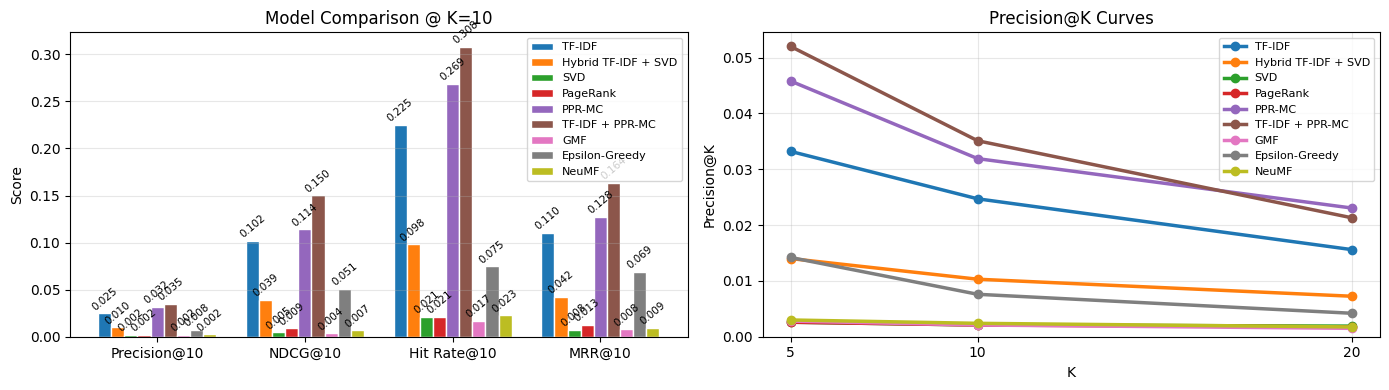

saved -> model_comparison.png


In [122]:
def _hybrid_batch_score(indices: list[int]) -> np.ndarray:
    """Batch cosine similarities using pre-computed text SVD embeddings."""
    global hybrid_embeddings
    if hybrid_embeddings is None or not isinstance(hybrid_embeddings, np.memmap):
        hybrid_embeddings = np.load(OUTPUT_DIR / "hybrid_embeddings.npy", mmap_mode="r")
    query_embeddings = hybrid_embeddings[indices]
    scores = linear_kernel(query_embeddings, hybrid_embeddings)
    return scores

hybrid_results = evaluate_model(
    "Hybrid TF-IDF + SVD",
    batch_score_fn=_hybrid_batch_score,
    batch_size=100,
)

compare_models()


In [123]:
assert "Hybrid TF-IDF + SVD" in MODEL_RESULTS, "Hybrid TF-IDF+SVD results not in MODEL_RESULTS"
_ndcg_h = MODEL_RESULTS["Hybrid TF-IDF + SVD"][10].get("NDCG", 0)
print(f"Hybrid TF-IDF+SVD NDCG@10 = {_ndcg_h:.4f}")

Hybrid TF-IDF+SVD NDCG@10 = 0.0393


### 7.9 - Model Comparison


Model Comparison  @K=10
Metric                           TF-IDF  Hybrid TF-IDF + SVD                  SVD             PageRank               PPR-MC      TF-IDF + PPR-MC                  GMF       Epsilon-Greedy                NeuMF
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Precision                        0.0247               0.0103               0.0021               0.0021               0.0319               0.0351               0.0021               0.0076               0.0024
Recall                           0.1486               0.0592               0.0068               0.0102               0.1632               0.2088               0.0042               0.0488               0.0093
NDCG                             0.1021               0.0393               0.0048               0.0089               0.1141               0.150

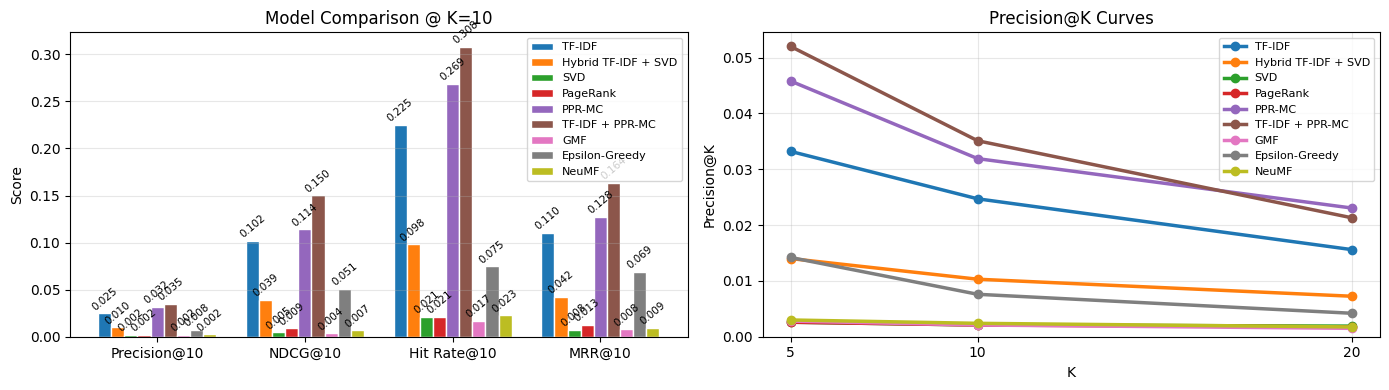

saved -> model_comparison.png


In [124]:
compare_models()

---
## Section 8 - Export

Download these files from Google Drive and place them alongside `app.py`.

### Core dataset (required for app.py to start)

| File | Purpose |
|---|---|
| `papers.csv` | Paper metadata: paper_idx, arxiv_id, title, abstract, categories, year, cite_pop |
| `citations.csv` | In-sample citation edges: source_idx, target_idx — required for PPR-MC model |
| `tfidf_vectorizer.pkl` | Fitted TF-IDF vectorizer |
| `tfidf_matrix.npz` | Pre-built TF-IDF sparse matrix |

### Model artifacts (optional — each unlocks one or more UI models)

| File | Unlocks |
|---|---|
| `paper_embeddings.npy` | SVD model |
| `pagerank_vector.npy` | PageRank model |
| `hybrid_embeddings.npy` | Hybrid TF-IDF + SVD model |
| `gmf_model.pt` | GMF model |
| `neumf_model.pt` | NeuMF model |

PPR-MC, TF-IDF+PPR-MC, and Epsilon-Greedy load automatically from `citations.csv` and
the TF-IDF artifacts — no separate weights file needed.

### How to download

Run the code cell below to save all available artifacts to Drive, then run
`python download_data.py` locally to fetch everything.


In [125]:
import os
import numpy as np

print(f"Files in {OUTPUT_DIR}:")
print()

total = 0
checkpoint_total = 0

for p in sorted(OUTPUT_DIR.iterdir()):
    if not p.is_file():
        continue
    sz = p.stat().st_size
    if p.name.startswith("_ckpt"):
        checkpoint_total += sz
        continue
    total += sz
    print(f"  {p.name:<40s}  {sz / 1e6:8.2f} MB")

print()
print(f"  Total (excluding checkpoints) : {total / 1e6:8.2f} MB")
print(f"  Checkpoint files              : {checkpoint_total / 1e6:8.2f} MB")
print()

# Save SVD paper embeddings if available.
if "paper_embeddings" in globals() and paper_embeddings is not None:
    emb_path = OUTPUT_DIR / "paper_embeddings.npy"
    np.save(emb_path, paper_embeddings)
    print(f"  saved paper_embeddings.npy  ({emb_path.stat().st_size / 1e6:.2f} MB)")

# Save hybrid TF-IDF+SVD text embeddings if available.
if "hybrid_embeddings" in globals() and hybrid_embeddings is not None:
    hyb_path = OUTPUT_DIR / "hybrid_embeddings.npy"
    np.save(hyb_path, np.array(hybrid_embeddings))
    print(f"  saved hybrid_embeddings.npy ({hyb_path.stat().st_size / 1e6:.2f} MB)")

# Save PageRank vector if available.
if "pagerank_vector" in globals() and pagerank_vector is not None:
    pr_path = OUTPUT_DIR / "pagerank_vector.npy"
    np.save(pr_path, pagerank_vector)
    print(f"  saved pagerank_vector.npy   ({pr_path.stat().st_size / 1e6:.2f} MB)")

# Save neural model state dicts for any model that was trained this session.
_model_saves = {
    "gmf_model.pt":        "gmf_model",
    "neumf_model.pt":      "neumf_model",
    }

import torch

for filename, var_name in _model_saves.items():
    model_obj = globals().get(var_name)
    if model_obj is not None:
        save_path = OUTPUT_DIR / filename
        torch.save(model_obj.state_dict(), save_path)
        print(f"  saved {filename:<32s}  ({save_path.stat().st_size / 1e6:.2f} MB)")

print()
print("Export complete.")

Files in /content/drive/MyDrive/cmpe_256_project_files:

  _checkpoint_citations_raw.csv                94.74 MB
  _checkpoint_papers.csv                      621.86 MB
  _checkpoint_s2_fields.json                   31.29 MB
  arXiv_src_2212_086.jsonl                     10.74 MB
  baseline_metrics.png                          0.10 MB
  citation_pop.csv                              5.64 MB
  citations.csv                                35.48 MB
  gmf_model.pt                                 33.19 MB
  hybrid_embeddings.npy                       249.30 MB
  hybrid_gmf_model.pt                          33.22 MB
  model_comparison.png                          0.17 MB
  neumf_model.pt                              249.32 MB
  paper_embeddings.npy                         66.37 MB
  papers.csv                                  646.44 MB
  tfidf_matrix.npz                            258.90 MB
  tfidf_vectorizer.pkl                          2.06 MB

  Total (excluding checkpoints) :  2338.81 MB
